In [1]:
# =============================================================================
# LIGHTCONE GENERATION - MINIMAL & CLEAN VERSION
# py21cmfast v3.4
# =============================================================================

# =============================================================================
# CELL 1: Imports
# =============================================================================
import numpy as np
import matplotlib as mpl
#matplotlib.use('Agg')  # Use non-interactive backend
import matplotlib.pyplot as plt
import py21cmfast as p21c
from py21cmfast import plotting

import os
from datetime import datetime

print(f"py21cmfast version: {p21c.__version__}")

# =============================================================================
# CELL 1a0: Create Output Directory for Plots
# =============================================================================
plot_dir = "16March2026_lightcone_plots_v3"

# Create directory if it doesn't exist
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)
    print(f"Created directory: {plot_dir}")
else:
    print(f"Directory already exists: {plot_dir}")

print(f"All plots will be saved to: {os.path.abspath(plot_dir)}")


import matplotlib as mpl
import matplotlib.pyplot as plt



# =============================================================================
# CELL 1a: Define Minimal User Parameters
# Only specify what differs from defaults or what's required
# =============================================================================

# Basic simulation parameters
user_params = p21c.UserParams(
    HII_DIM=128,                      # Resolution of ionization/spin-temp grids
    BOX_LEN=800.0,                    # Box size in comoving Mpc
    USE_INTERPOLATION_TABLES=True,    # Speed up calculations
    N_THREADS=8                       # Number of CPU threads
)

# Redshift range for the lightcone
z_min = 5.0                           # Final/lowest redshift
z_max = 20.0                          # Highest redshift to simulate

print("User parameters defined:")
print(user_params)


# =============================================================================
# CELL 1b : Print Default Parameters (Optional - for reference)
# See what py21cmfast uses by default if you don't specify
# =============================================================================

print("\n=== DEFAULT COSMOLOGY ===")
print(p21c.CosmoParams())

print("\n=== DEFAULT ASTROPHYSICS ===")
print(p21c.AstroParams())

print("\n=== DEFAULT FLAGS ===")
print(p21c.FlagOptions())





py21cmfast version: 3.4.0
Created directory: 16March2026_lightcone_plots_v3
All plots will be saved to: /home/swanith/Desktop/Project2/Plots/Lightconer_v3/16March2026_lightcone_plots_v3
User parameters defined:
UserParams:
    BOX_LEN                 : 800.0
    DIM                     : 384
    FAST_FCOLL_TABLES       : False
    HII_DIM                 : 128
    HMF                     : 1
    KEEP_3D_VELOCITIES      : False
    MINIMIZE_MEMORY         : False
    NON_CUBIC_FACTOR        : 1.0
    NO_RNG                  : False
    N_THREADS               : 8
    PERTURB_ON_HIGH_RES     : False
    POWER_SPECTRUM          : 0
    USE_2LPT                : True
    USE_FFTW_WISDOM         : False
    USE_INTERPOLATION_TABLES: True
    USE_RELATIVE_VELOCITIES : False
    

=== DEFAULT COSMOLOGY ===
CosmoParams:
    OMb        : 0.04897468161869667
    OMm        : 0.30964144154550644
    POWER_INDEX: 0.9665
    SIGMA_8    : 0.8102
    hlittle    : 0.6766
    

=== DEFAULT ASTROPHYSICS

In [4]:
# =============================================================================
# SIMPLE LIGHTCONE PLOTTING - NO TICK CUSTOMIZATION
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib as mpl

PDF_STYLE = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'font.size': 30,
    'axes.labelsize': 29,
    'axes.titlesize': 40,
    'xtick.labelsize': 30,
    'ytick.labelsize': 30,
    'legend.fontsize': 20,
    'figure.titlesize': 28,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.minor.width': 0.8,
    'ytick.minor.width': 0.8,
    'axes.linewidth': 1.0,
    'lines.linewidth': 1.8,
    'lines.markersize': 5,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
}

PNG_STYLE = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'font.size': 15,
    'axes.labelsize': 25,
    'axes.titlesize': 18,
    'xtick.labelsize': 25,
    'ytick.labelsize': 25,
    'legend.fontsize': 25,
    'figure.titlesize': 15,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'axes.linewidth': 1.0,
    'lines.linewidth': 1.5,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
}

def save_pdf_png(plot_func, plot_dir, plot_name, title=None):
    """Save plot as both PDF and PNG"""
    with mpl.rc_context(PDF_STYLE):
        fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
        plot_func(ax)
        ax.set_title("")
        fig.savefig(f"{plot_dir}/{plot_name}.pdf")
        plt.close(fig)

    with mpl.rc_context(PNG_STYLE):
        fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
        plot_func(ax)
        if title is not None:
            ax.set_title(title, fontweight='bold')
        fig.savefig(f"{plot_dir}/{plot_name}.png")
        plt.close(fig)

def redshift_to_time(z, H0=67.4, Om0=0.315):
    """Convert redshift to time since Big Bang in Gyr"""
    from astropy.cosmology import FlatLambdaCDM
    import astropy.units as u
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    return cosmo.age(z).to(u.Gyr).value

def make_lightcone_plotter(
    lightcone,
    field,
    cmap=None,
    clim=None,
    cbar_label=None,
    labelsize=16,
    axlabelsize=20,
    user_params=None,
    add_time_axis=False,
):
    """Create a lightcone plotting function"""
    def _plot(ax):
        import numpy as np
        fig = ax.figure
        
        # Plot the lightcone
        plotting.lightcone_sliceplot(lightcone, field, ax=ax, fig=fig)
        im = ax.images[0]
        
        # Apply colormap and limits
        if cmap is not None:
            im.set_cmap(cmap)
        if clim is not None:
            im.set_clim(*clim)
        
        # Y-axis label
        if user_params is not None:
            ax.set_ylabel(r'y-axis [Mpc]', fontsize=axlabelsize) #[$h^{-1}$ cMpc]
        
        # Tick formatting
        ax.tick_params(axis='both', which='major', labelsize=labelsize)
        ax.xaxis.label.set_size(axlabelsize)
        ax.yaxis.label.set_size(axlabelsize)
        
        # Add time axis on top if requested
        ax2 = None
        if add_time_axis:
            ax2 = ax.twiny()
            xlim = ax.get_xlim()
            z_min, z_max = xlim
            t_min = redshift_to_time(z_max)
            t_max = redshift_to_time(z_min)
            
            ax2.set_xlim(t_min, t_max)
            ax2.set_xlabel('Time Since Big Bang [Gyr]', fontsize=axlabelsize)
            
            # Smart tick spacing
            time_range = t_max - t_min
            if time_range < 2:
                tick_spacing = 0.2
            elif time_range < 5:
                tick_spacing = 0.5
            elif time_range < 10:
                tick_spacing = 1.0
            else:
                tick_spacing = 2.0
            
            first_tick = np.ceil(t_min / tick_spacing) * tick_spacing
            last_tick = np.floor(t_max / tick_spacing) * tick_spacing
            t_ticks = np.arange(first_tick, last_tick + tick_spacing/2, tick_spacing)
            
            if len(t_ticks) > 8:
                t_ticks = t_ticks[::2]
            
            ax2.set_xticks(t_ticks)
            ax2.set_xticklabels([f'{t:.1f}' for t in t_ticks])
            ax2.tick_params(axis='x', which='major', labelsize=labelsize, direction='in')
            ax2.tick_params(axis='x', which='minor', direction='in')
            ax2.minorticks_on()
        
        # Format colorbar
        for cax in fig.axes:
            if cax is ax:
                continue
            if ax2 is not None and cax is ax2:
                continue
            cax.tick_params(labelsize=labelsize)
            cax.xaxis.label.set_size(axlabelsize)
            if cbar_label is not None:
                cax.set_xlabel(cbar_label)
    
    return _plot

print("✓ Simple lightcone plotter loaded")

# =============================================================================
# USAGE
# =============================================================================
"""
lightcone_plots = {
    "xH_box": {
        "title": r"Neutral Fraction Lightcone",
        "plot_name": "xHI_lightcone",
        "cbar_label": r"$x_{\mathrm{HI}}$",
        "labelsize": 20,
        "axlabelsize": 27,
        "add_time_axis": True,
    },
}

for field, cfg in lightcone_plots.items():
    plot_func = make_lightcone_plotter(
        lightcone=lightcone,
        field=field,
        cmap=cfg.get("cmap"),
        cbar_label=cfg.get("cbar_label"),
        labelsize=cfg.get("labelsize", 16),
        axlabelsize=cfg.get("axlabelsize", 22),
        user_params=user_params,
        add_time_axis=cfg.get("add_time_axis", False),
    )
    
    with mpl.rc_context(PNG_STYLE):
        fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
        plot_func(ax)
        plt.show()
    
    save_pdf_png(
        plot_func=plot_func,
        plot_dir=plot_dir,
        plot_name=cfg["plot_name"],
        title=cfg.get("title"),
    )
"""

✓ Simple lightcone plotter loaded


'\nlightcone_plots = {\n    "xH_box": {\n        "title": r"Neutral Fraction Lightcone",\n        "plot_name": "xHI_lightcone",\n        "cbar_label": r"$x_{\\mathrm{HI}}$",\n        "labelsize": 20,\n        "axlabelsize": 27,\n        "add_time_axis": True,\n    },\n}\n\nfor field, cfg in lightcone_plots.items():\n    plot_func = make_lightcone_plotter(\n        lightcone=lightcone,\n        field=field,\n        cmap=cfg.get("cmap"),\n        cbar_label=cfg.get("cbar_label"),\n        labelsize=cfg.get("labelsize", 16),\n        axlabelsize=cfg.get("axlabelsize", 22),\n        user_params=user_params,\n        add_time_axis=cfg.get("add_time_axis", False),\n    )\n    \n    with mpl.rc_context(PNG_STYLE):\n        fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)\n        plot_func(ax)\n        plt.show()\n    \n    save_pdf_png(\n        plot_func=plot_func,\n        plot_dir=plot_dir,\n        plot_name=cfg["plot_name"],\n        title=cfg.get("title"),\n    )


=== RUNNING LIGHTCONE ===
Redshift range: z = 5.0 → 20.0
Box size: 800.0 Mpc
Resolution: 128³ cells

Lightcone simulation complete!
Lightcone shape: (128, 128, 483)
Number of redshift slices: 483

=== LIGHTCONE CONTENTS ===
Redshift axis: z ∈ [5.00, 20.03]
Comoving distance axis: r ∈ [7946.5 Mpc, 10959.0 Mpc] Mpc

Available fields:
  brightness_temp      -> shape (128, 128, 483), dtype float32
  density              -> shape (128, 128, 483), dtype float32
  xH_box               -> shape (128, 128, 483), dtype float32
  velocity             -> shape (128, 128, 483), dtype float32

Trimmed axes:
  Redshift: 482 slices from z=5.00 to z=19.95
  Distance: 7946.5 Mpc to 10952.7 Mpc Mpc


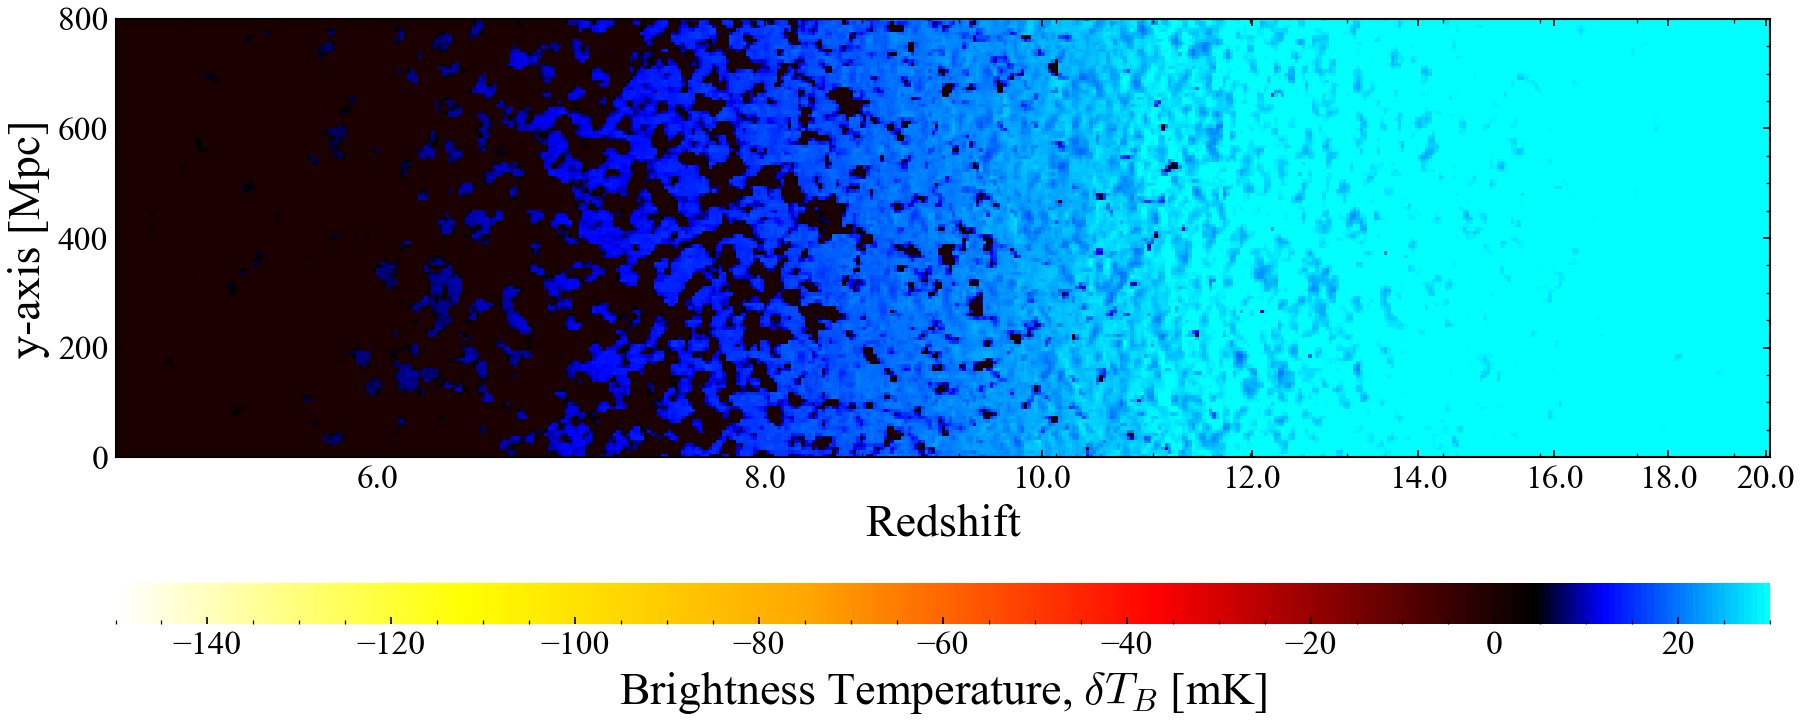

Saved: brightness_temp_lightcone


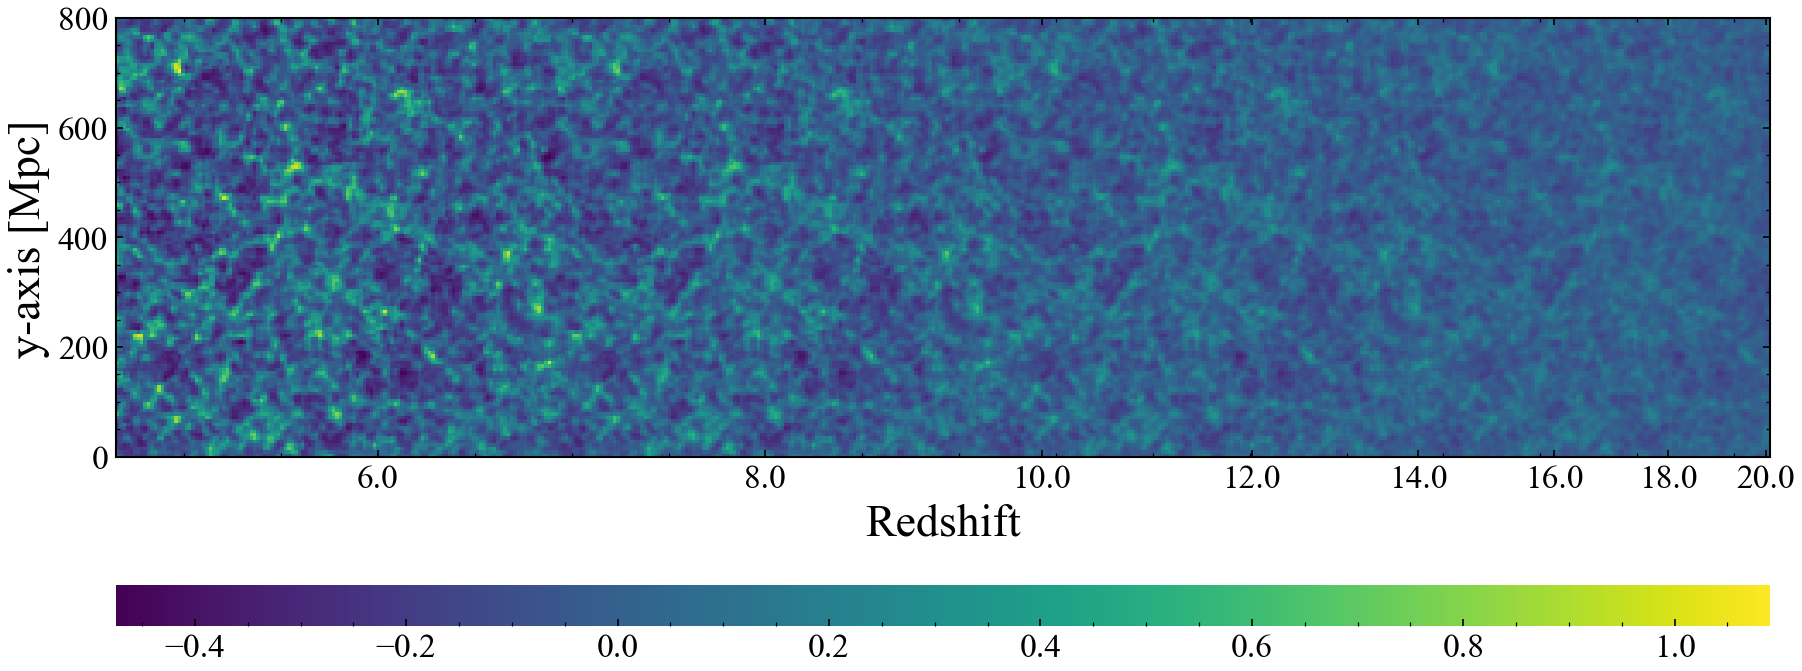

Saved: density_lightcone


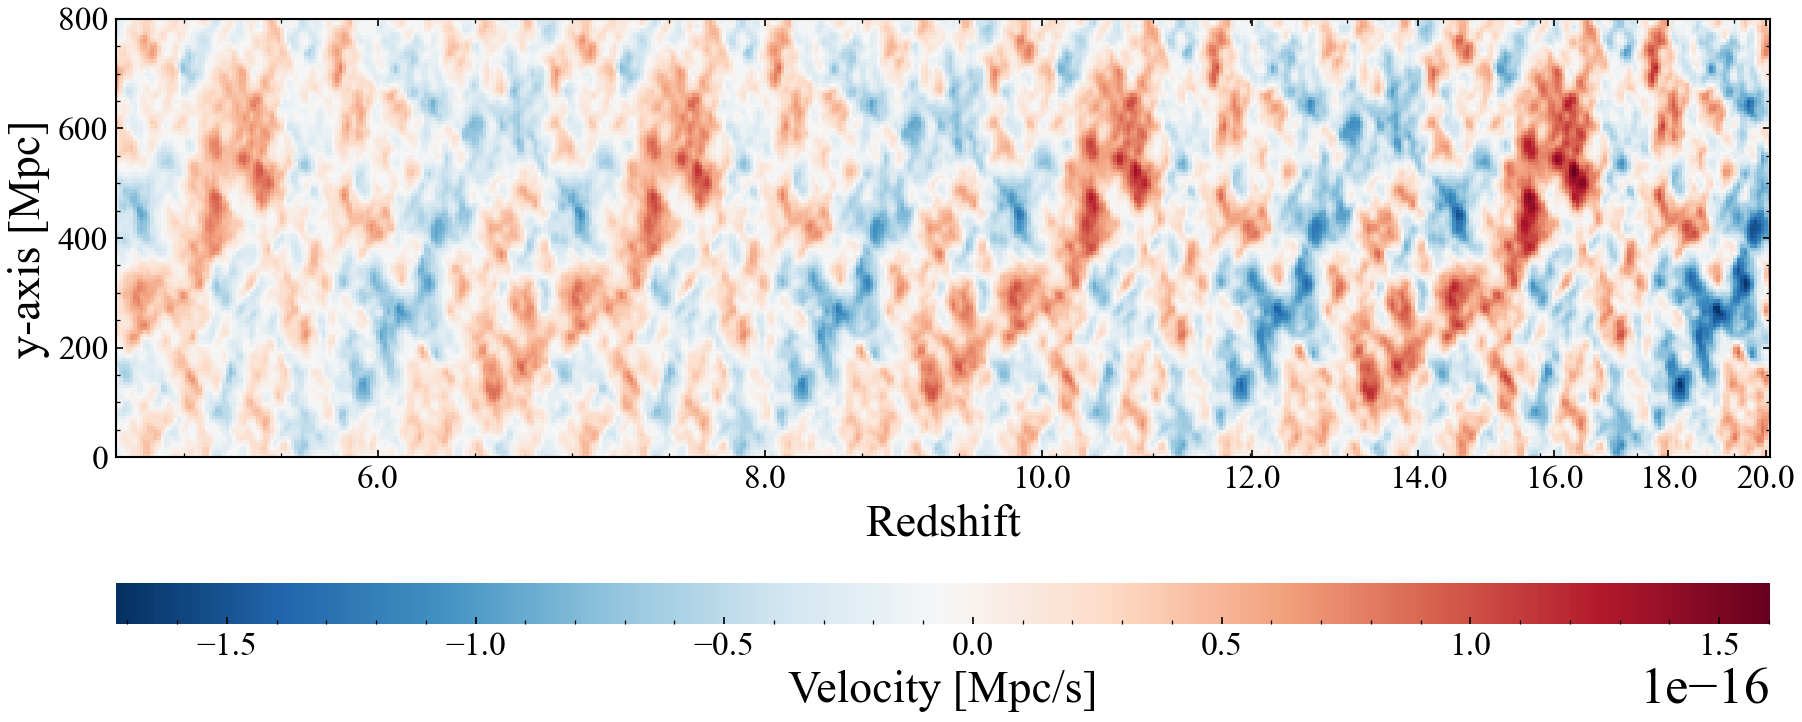

Saved: velocity_z_lightcone


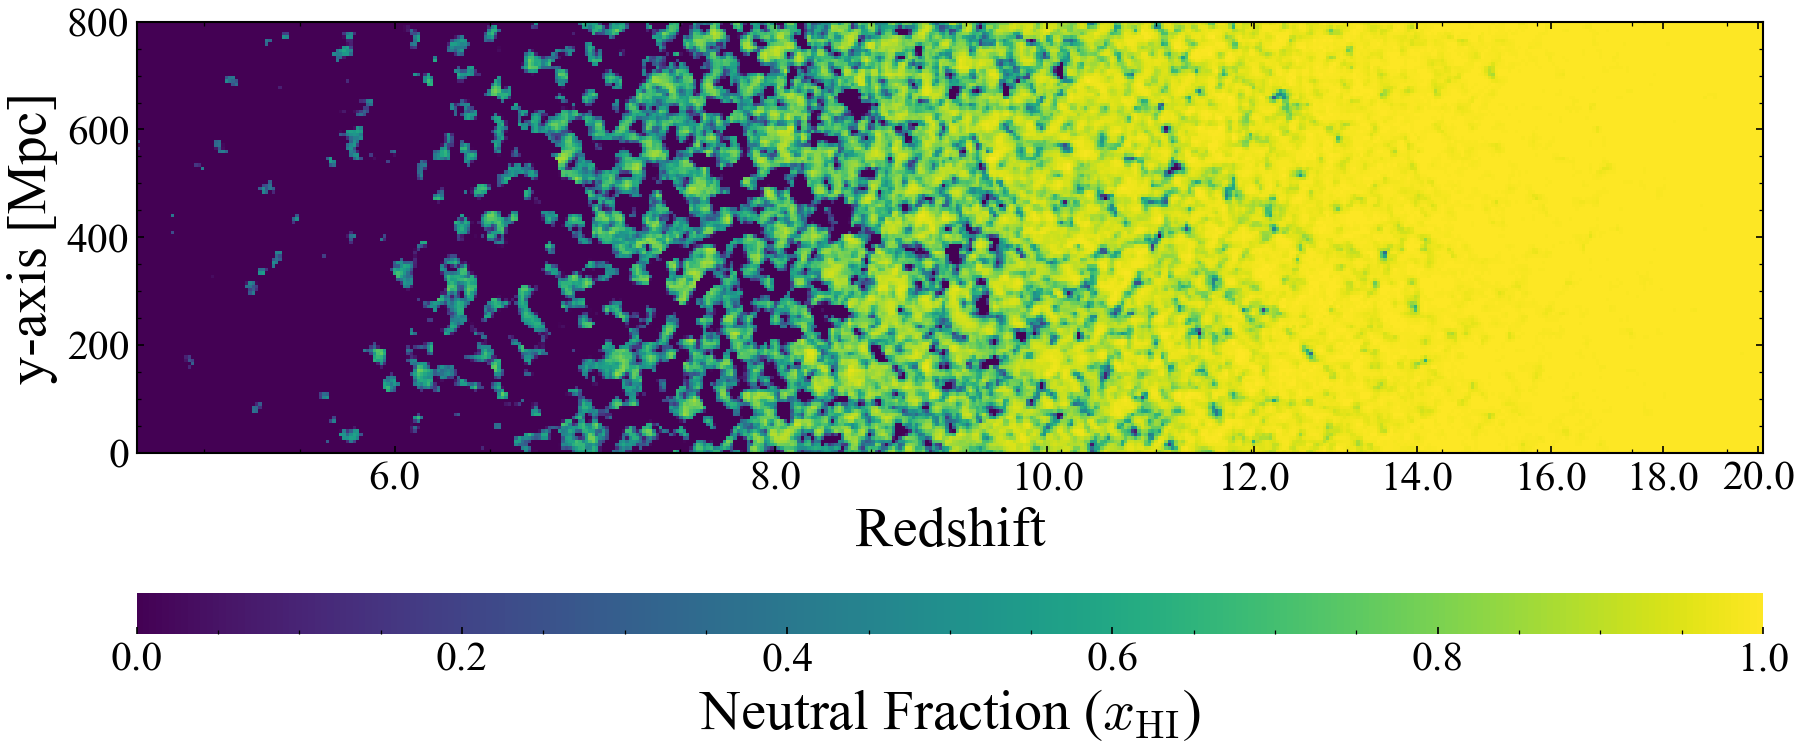

Saved: xHI_lightcone

=== ALL PLOTS SAVED ===
Location: /home/swanith/Desktop/Project2/Plots/Lightconer_v3/16March2026_lightcone_plots_v3
Files created:
  - brightness_temp_lightcone.pdf
  - brightness_temp_lightcone.png
  - density_lightcone.pdf
  - density_lightcone.png
  - velocity_z_lightcone.pdf
  - velocity_z_lightcone.png
  - xHI_lightcone.pdf
  - xHI_lightcone.png


In [5]:
# =============================================================================
# CELL 2: Run Lightcone Simulation
# Using defaults for cosmo/astro/flags - only override if needed
# =============================================================================

print("\n=== RUNNING LIGHTCONE ===")
print(f"Redshift range: z = {z_min} → {z_max}")
print(f"Box size: {user_params.BOX_LEN} Mpc")
print(f"Resolution: {user_params.HII_DIM}³ cells")

lightcone = p21c.run_lightcone(
    redshift=z_min,                           # Final redshift
    max_redshift=z_max,                       # Starting redshift
    lightcone_quantities=('brightness_temp', 'density', 'xH_box', 'velocity'),
    #global_quantities=('xH_box'),
    user_params=user_params,
    random_seed=37,                           # For reproducibility
    direc='_cache'                            # Cache directory
)

print("\nLightcone simulation complete!")
print(f"Lightcone shape: {lightcone.brightness_temp.shape}")
print(f"Number of redshift slices: {len(lightcone.lightcone_redshifts)}")


# =============================================================================
# CELL 2a: Inspect Lightcone Structure
# What fields are available and their shapes
# =============================================================================

print("\n=== LIGHTCONE CONTENTS ===")
print(f"Redshift axis: z ∈ [{lightcone.lightcone_redshifts.min():.2f}, "
      f"{lightcone.lightcone_redshifts.max():.2f}]")
print(f"Comoving distance axis: r ∈ [{lightcone.lightcone_distances.min():.1f}, "
      f"{lightcone.lightcone_distances.max():.1f}] Mpc")

print("\nAvailable fields:")
for field in ['brightness_temp', 'density', 'xH_box', 'velocity']:
    if hasattr(lightcone, field):
        data = getattr(lightcone, field)
        print(f"  {field:20s} -> shape {data.shape}, dtype {data.dtype}")


# =============================================================================
# CELL 2b: Extract Redshift and Distance Axes
# Trim to the requested redshift range if needed
# =============================================================================

# Full axes from lightcone
red_axis = lightcone.lightcone_redshifts      # Redshift per slice
pos_axis = lightcone.lightcone_distances      # Comoving distance [Mpc]

# Trim to z <= z_max (in case simulation went slightly beyond)
ind_z = np.where(red_axis <= z_max)[0]
red_axis = red_axis[ind_z]
pos_axis = pos_axis[ind_z]

print(f"\nTrimmed axes:")
print(f"  Redshift: {len(red_axis)} slices from z={red_axis.min():.2f} to z={red_axis.max():.2f}")
print(f"  Distance: {pos_axis.min():.1f} to {pos_axis.max():.1f} Mpc")


# =============================================================================
# CELL 2c: LIGHTCONE PLOTS
# =============================================================================

# Updated lightcone_plots configuration
lightcone_plots = {
    "brightness_temp": {
        "title": "21cm Brightness Temperature",
        "plot_name": "brightness_temp_lightcone",
    },
    "density": {
        "title": r"Matter Density Field ($\delta$)",
        "plot_name": "density_lightcone",
    },
    "velocity": {
        "title": "Line-of-Sight Velocity",
        "plot_name": "velocity_z_lightcone",
        "cmap": "RdBu_r",
        "cbar_label": "Velocity [Mpc/s]",
    },
    "xH_box": {
        "title": r"Neutral Fraction Lightcone",
        "plot_name": "xHI_lightcone",
        "cbar_label": r"Neutral Fraction ($x_{\mathrm{HI}}$)",
        "labelsize": 20,
        "axlabelsize": 27,
        "add_time_axis": False,
    },
}

for field, cfg in lightcone_plots.items():
    plot_func = make_lightcone_plotter(
        lightcone=lightcone,
        field=field,
        cmap=cfg.get("cmap"),
        cbar_label=cfg.get("cbar_label"),
        labelsize=cfg.get("labelsize", 16),
        axlabelsize=cfg.get("axlabelsize", 22),
        user_params=user_params,
        add_time_axis=cfg.get("add_time_axis", False),
    )
    
    # Preview PDF style
    with mpl.rc_context(PNG_STYLE):
        fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
        plot_func(ax)
        plt.show()
    
    # Save PDF + PNG
    save_pdf_png(
        plot_func=plot_func,
        plot_dir=plot_dir,
        plot_name=cfg["plot_name"],
        title=cfg.get("title") if cfg.get("plot_name") != "xHI_lightcone" else None,  # No title for xHI
    )
    print(f"Saved: {cfg['plot_name']}")
# =============================================================================
# Summary
# =============================================================================
print(f"\n=== ALL PLOTS SAVED ===")
print(f"Location: {os.path.abspath(plot_dir)}")
print(f"Files created:")
for fname in sorted(os.listdir(plot_dir)):
    print(f"  - {fname}")

In [6]:
# =============================================================================
# CELL 3: Extract 3D Fields (if needed for further analysis)
# Trimmed to the redshift range of interest
# =============================================================================

# Extract fields with proper indexing
brightness_temp = lightcone.brightness_temp[:, :, ind_z]  # [mK]
density_field   = 1+ lightcone.density[:, :, ind_z]          # 1 + δ
neutral_frac    = lightcone.xH_box[:, :, ind_z]           # xHI
velocity_los    = 1e17*lightcone.velocity[:, :, ind_z]         # [comoving km/s]

print("\n=== EXTRACTED 3D FIELDS ===")
print(f"Brightness temperature: {brightness_temp.shape}")
print(f"Density field:          {density_field.shape}")
print(f"Neutral fraction:       {neutral_frac.shape}")


# =============================================================================
# CELL 3a: Summary Statistics (Optional)
# Quick overview of the simulation results
# =============================================================================

print("\n=== SUMMARY STATISTICS ===")
print(f"Brightness temperature: min={brightness_temp.min():.1f} mK, "
      f"max={brightness_temp.max():.1f} mK, mean={brightness_temp.mean():.1f} mK")
print(f"Neutral fraction:       min={neutral_frac.min():.3f}, "
      f"max={neutral_frac.max():.3f}, mean={neutral_frac.mean():.3f}")
print(f"Density (1+δ):          min={density_field.min():.3f}, "
      f"max={density_field.max():.3f}, mean={density_field.mean():.3f}")
print(f"Velocity_z (1e-17 Mpc/s):          min={velocity_los.min():.3f}, "
      f"max={velocity_los.max():.3f}, mean={velocity_los.mean():.3f}")

# =============================================================================
# NOTES ON CUSTOMIZATION:
# 
# If you want to change cosmology/astrophysics from defaults, add:
#
#   cosmo_params = p21c.CosmoParams(
#       SIGMA_8=0.81,      # Matter power spectrum normalization
#       hlittle=0.68,      # Hubble parameter h
#       OMm=0.31,          # Total matter density
#       OMb=0.049,         # Baryon density
#       POWER_INDEX=0.965  # Primordial spectral index n_s
#   )
#
#   astro_params = p21c.AstroParams(
#       HII_EFF_FACTOR=30.0,  # Ionization efficiency
#       R_BUBBLE_MAX=30.0,    # Maximum bubble size [Mpc]
#       L_X=1e40              # X-ray luminosity per SFR
#   )
#
#   flag_options = p21c.FlagOptions(
#       USE_TS_FLUCT=True     # Include spin temperature fluctuations
#   )
#
# Then pass them to run_lightcone():
#   lightcone = p21c.run_lightcone(
#       ...,
#       cosmo_params=cosmo_params,
#       astro_params=astro_params,
#       flag_options=flag_options
#   )
# =============================================================================


=== EXTRACTED 3D FIELDS ===
Brightness temperature: (128, 128, 482)
Density field:          (128, 128, 482)
Neutral fraction:       (128, 128, 482)

=== SUMMARY STATISTICS ===
Brightness temperature: min=0.0 mK, max=58.8 mK, mean=18.0 mK
Neutral fraction:       min=0.000, max=1.000, mean=0.589
Density (1+δ):          min=0.412, max=3.230, mean=1.000
Velocity_z (1e-17 Mpc/s):          min=-23.159, max=23.457, mean=-0.044



=== INTERPOLATED IONIZATION FRACTION ===
x_e range: [0.0000, 0.9992]

=== GEOMETRIC QUANTITIES ===
s range: [7946.5 Mpc, 10952.7 Mpc] Mpc
ds: mean = 6.250 Mpc Mpc, std = 0.000 Mpc Mpc
Number of slices: 482

=== OPTICAL DEPTH ===
dτ range: [7.458399e-08 Mpc, 1.605852e-04 Mpc]
Total τ: 0.040152 Mpc
Integrated from z = 5.00 → 19.95


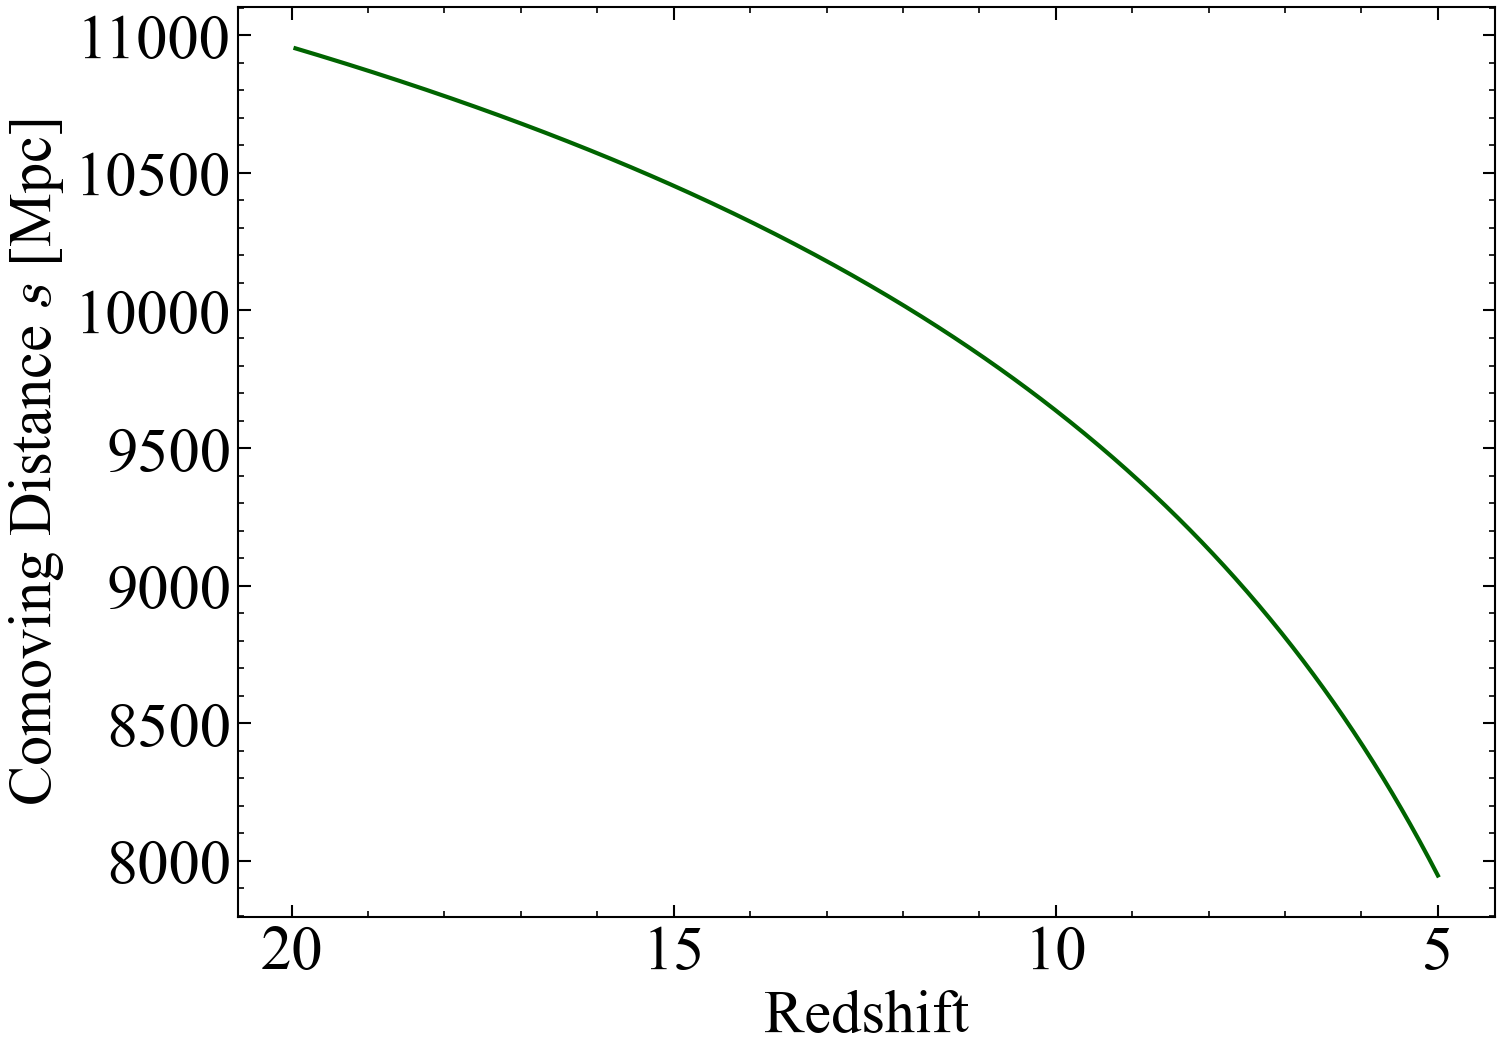

Saved: s_vs_z


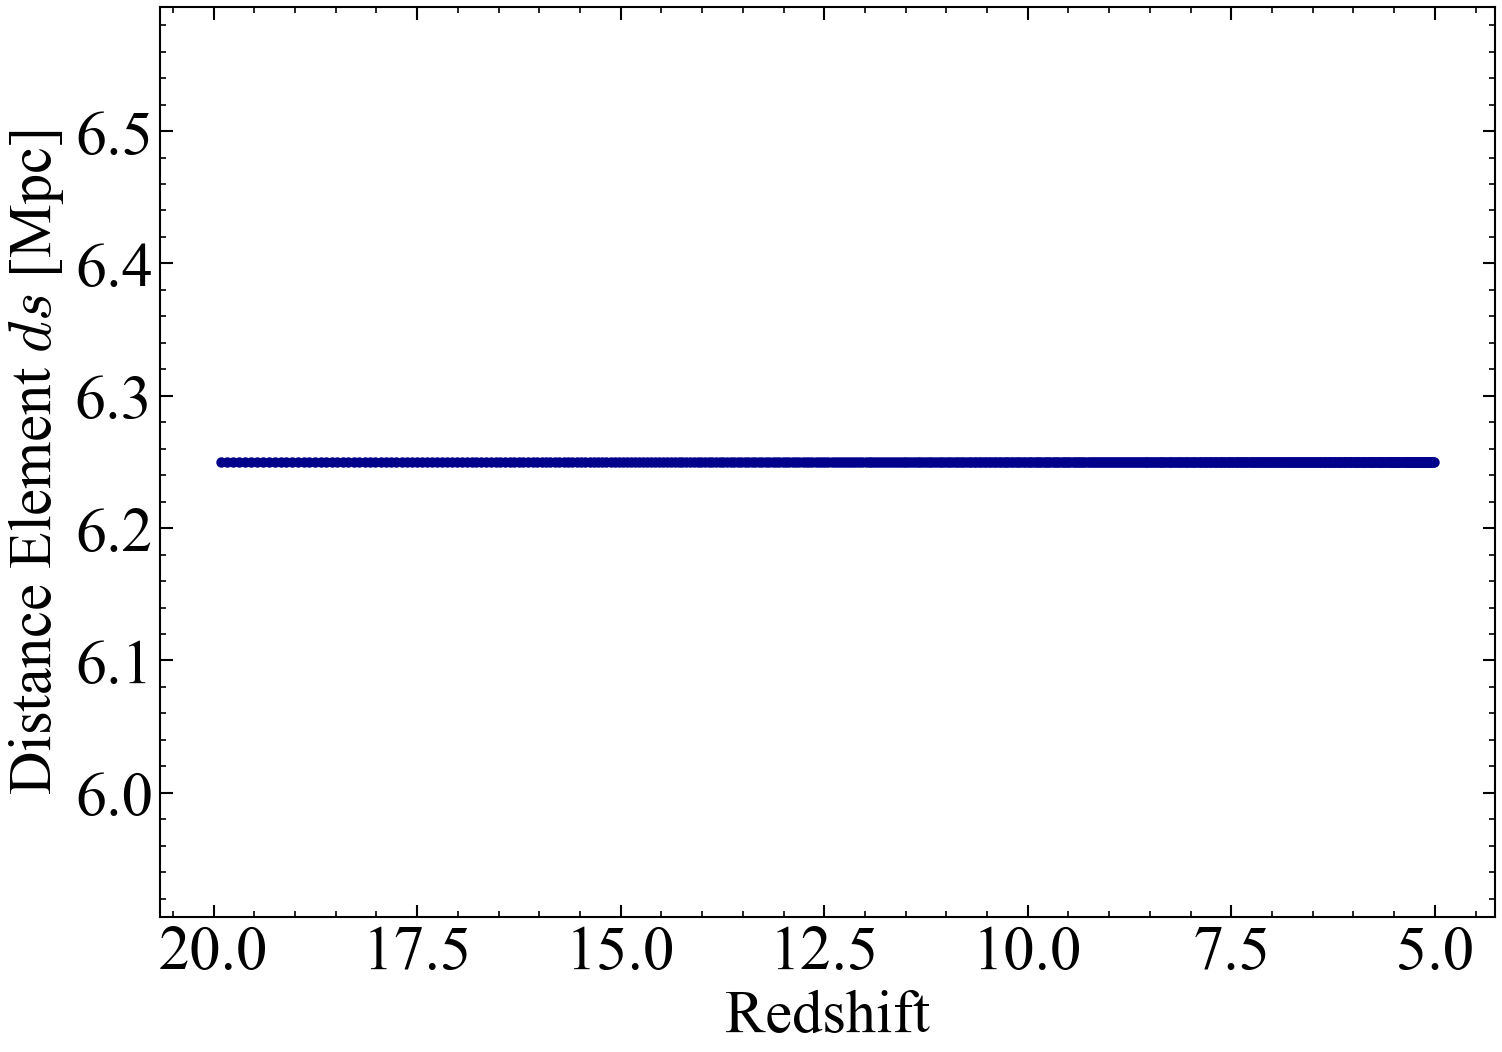

Saved: ds_vs_z
Reionization midpoint: z_re = 8.05
Reionization start (5%): z_start = 12.10
Reionization end (95%): z_end = 6.05
Reionization duration: Δz_re = 6.04


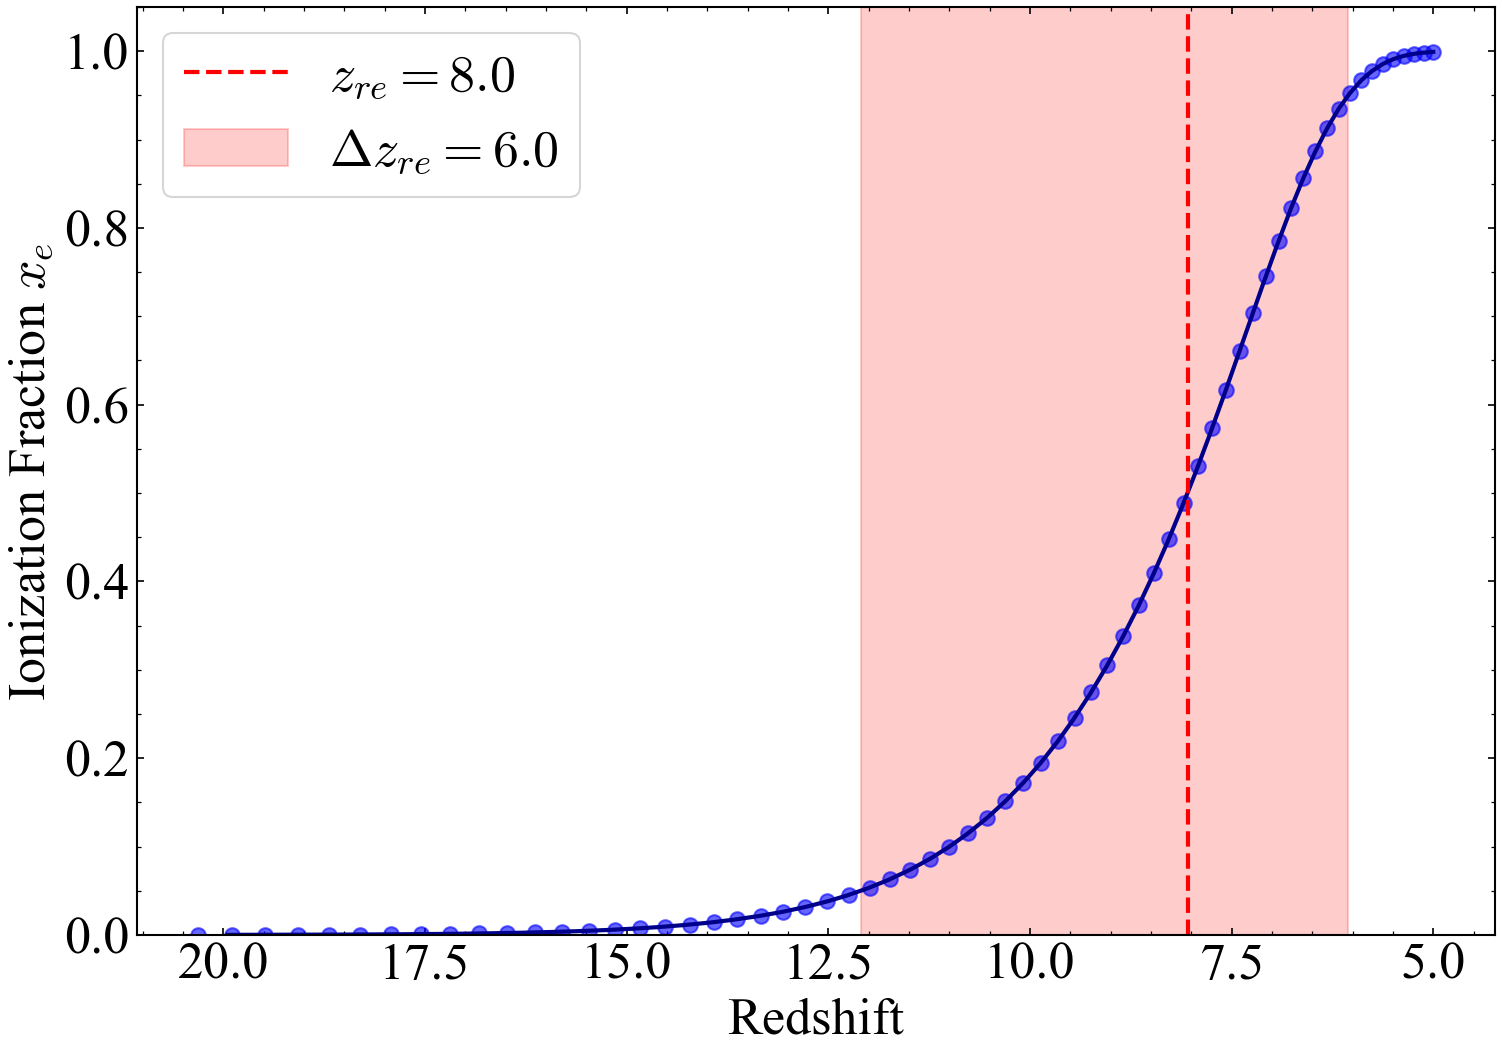

Saved: xe_vs_z


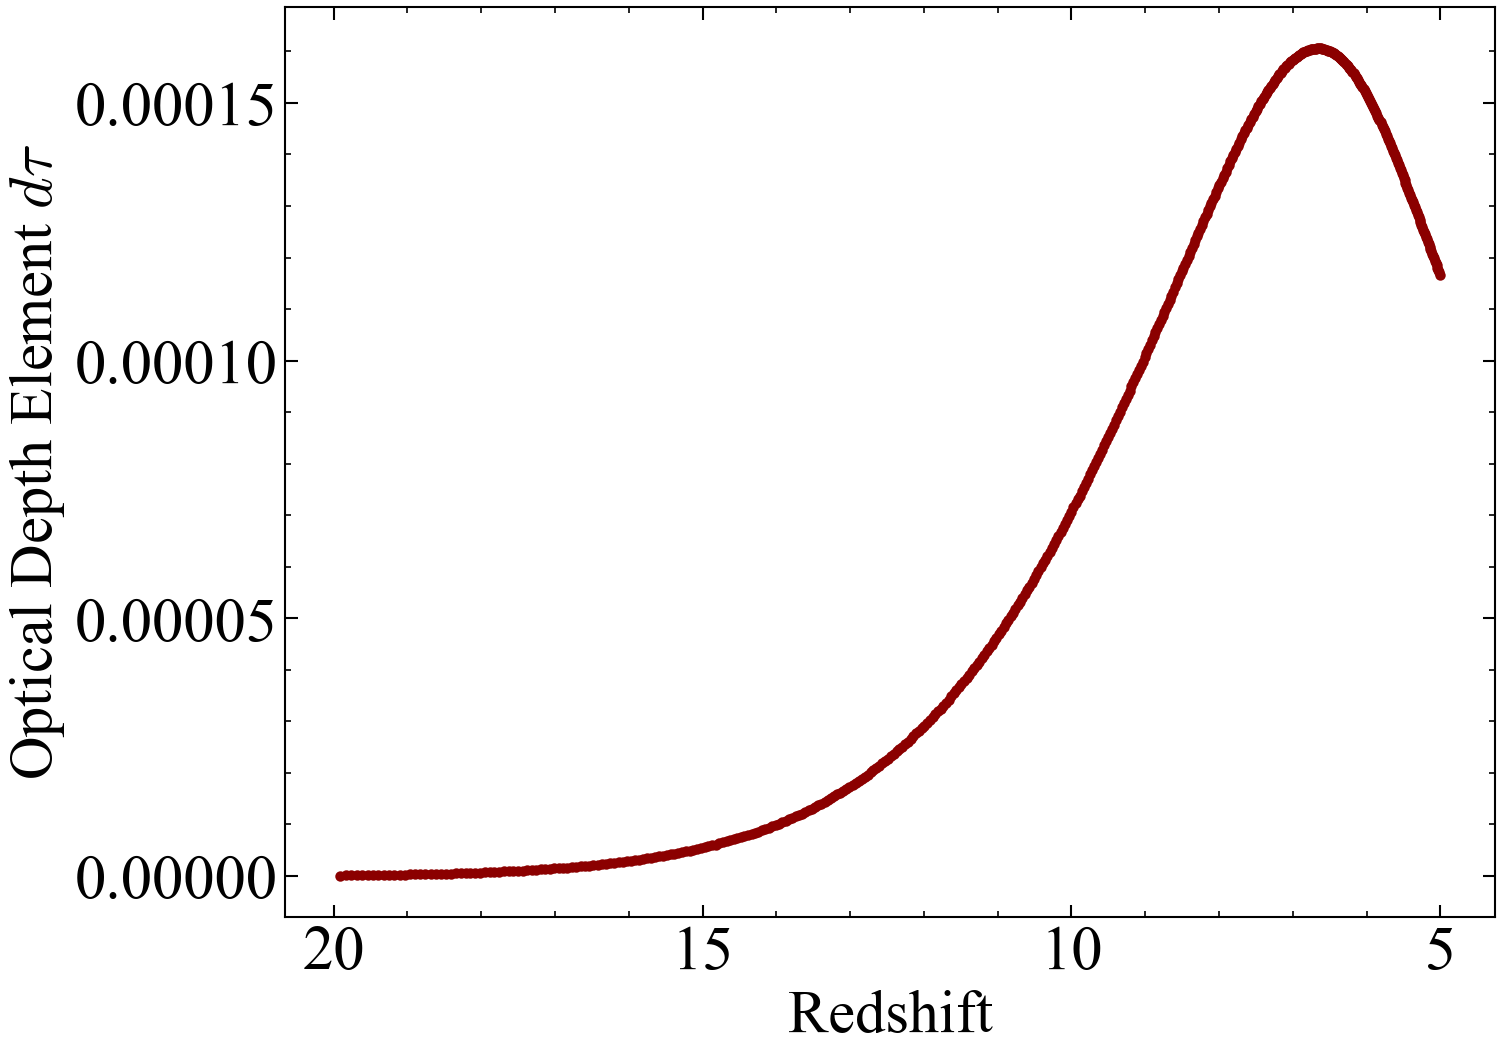

Saved: dtau_vs_z


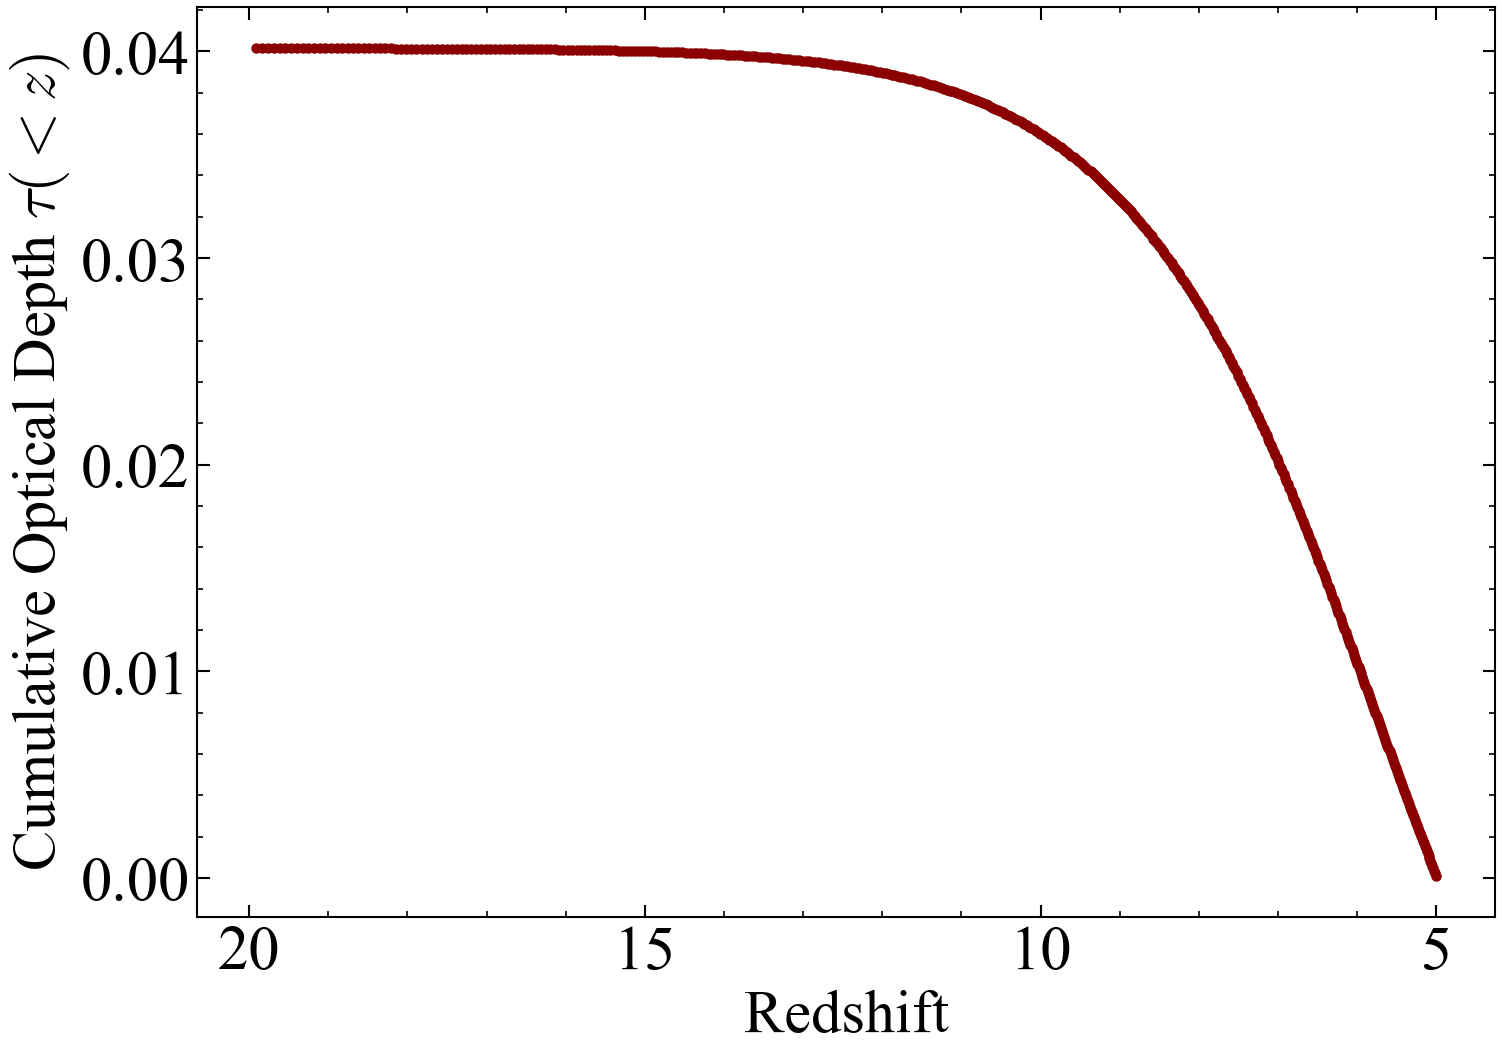

Saved: tau_vs_z

SUMMARY OF CALCULATIONS
Redshift range:           5.00 → 19.95
Comoving distance:        7946.5 Mpc → 10952.7 Mpc Mpc
Mean distance element:    6.250 Mpc Mpc
Ionization fraction:      0.0000 → 0.9992
Total optical depth:      τ = 0.040152 Mpc
Number of data points:    482


In [12]:
# =============================================================================
# COMPLETE CELL 4: Calculate and Plot s, ds, x_e, dτ, τ vs z
# Using interpolated x_e onto lightcone redshifts
# =============================================================================

# =============================================================================
# Step 1: Interpolate x_e onto lightcone redshifts
# =============================================================================

# Reverse node arrays to match lightcone order (low z → high z)
z_nodes_sorted = lightcone.node_redshifts[::-1]      # 5.0 → 20.3
xHI_nodes_sorted = lightcone.global_xH[::-1]
x_e_nodes_sorted = 1.0 - xHI_nodes_sorted

# Interpolate x_e onto lightcone redshift grid
x_e_interp = np.interp(red_axis, z_nodes_sorted, x_e_nodes_sorted)

print(f"\n=== INTERPOLATED IONIZATION FRACTION ===")
print(f"x_e range: [{x_e_interp.min():.4f}, {x_e_interp.max():.4f}]")

# =============================================================================
# Step 2: Extract/Calculate geometric quantities
# =============================================================================

# Comoving distance (already available)
s = pos_axis  # Comoving distance [Mpc]

# Distance element
ds = np.diff(s)  # [Mpc], length 963

# Midpoint values for integration
z_mid = 0.5 * (red_axis[:-1] + red_axis[1:])
x_e_mid = 0.5 * (x_e_interp[:-1] + x_e_interp[1:])

print(f"\n=== GEOMETRIC QUANTITIES ===")
print(f"s range: [{s.min():.1f}, {s.max():.1f}] Mpc")
print(f"ds: mean = {ds.mean():.3f} Mpc, std = {ds.std():.3f} Mpc")
print(f"Number of slices: {len(red_axis)}")

# =============================================================================
# Step 3: Calculate dτ and τ
# =============================================================================
# Physical constants for optical depth calculation
c_km_s = 2.998e5                    # Speed of light [km/s]
h = 0.6766                          # Hubble parameter (from default cosmology)
H0 = 100 * h                        # Hubble constant [km/s/Mpc]
Omega_b = 0.04897468161869667       # Baryon density (from default cosmology)
Omega_m = 0.30964144154550644       # Matter density (from default cosmology)

# Critical density of the universe [protons/cm^3]
rho_crit_p_cm3 = 1.88e-29 * h**2 / (1.67e-24)  # Convert to protons/cm^3
n_H0_cm3 = Omega_b * rho_crit_p_cm3             # Mean hydrogen number density [cm^-3]

# Thomson scattering cross section
sigma_T_cm2 = 6.65e-25              # [cm^2]

# Convert to Mpc units
cm_per_Mpc = 3.086e24
n_e0_Mpc3 = n_H0_cm3 * cm_per_Mpc**3
sigma_T_Mpc2 = sigma_T_cm2 / cm_per_Mpc**2

# Prefactor for dτ calculation
prefactor = n_e0_Mpc3 * sigma_T_Mpc2  # [Mpc^-1]
# Calculate dτ
dtau = prefactor * x_e_mid * (1.0 + z_mid)**2 * ds

# Cumulative optical depth
tau = np.cumsum(dtau)
tau_total = tau[-1]

print(f"\n=== OPTICAL DEPTH ===")
print(f"dτ range: [{dtau.min():.6e}, {dtau.max():.6e}]")
print(f"Total τ: {tau_total:.6f}")
print(f"Integrated from z = {red_axis.min():.2f} → {red_axis.max():.2f}")

# =============================================================================
# PLOT 1: Comoving Distance s vs z
# =============================================================================

def plot_s_vs_z(ax):
    ax.plot(red_axis, s, '-', linewidth=2, color='darkgreen')
    ax.set_xlabel('Redshift')
    ax.set_ylabel(r'Comoving Distance $s$ [Mpc]')
    ax.invert_xaxis()

plot_name = "s_vs_z"

with mpl.rc_context(PDF_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
    plot_s_vs_z(ax)
    plt.show()

save_pdf_png(
    plot_func=plot_s_vs_z,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title="Comoving Distance vs Redshift"
)

print(f"Saved: {plot_name}")


# =============================================================================
# PLOT 2: Distance Element ds vs z
# =============================================================================

def plot_ds_vs_z(ax):
    ax.plot(z_mid, ds, 'o-', linewidth=2, markersize=4, color='darkblue')
    ax.set_xlabel('Redshift')
    ax.set_ylabel(r'Distance Element $ds$ [Mpc]')
    ax.invert_xaxis()

plot_name = "ds_vs_z"

with mpl.rc_context(PDF_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
    plot_ds_vs_z(ax)
    plt.show()

save_pdf_png(
    plot_func=plot_ds_vs_z,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title="Distance Element vs Redshift"
)

print(f"Saved: {plot_name}")


# =============================================================================
# PLOT 3: Ionization Fraction x_e vs z
# =============================================================================
# Calculate reionization parameters
from scipy.interpolate import interp1d

# Find z where x_e = 0.5 (midpoint)
interp_z_from_xe = interp1d(x_e_interp, red_axis, bounds_error=False, fill_value='extrapolate')
z_re = float(interp_z_from_xe(0.5))

# Find z where x_e = 0.05 (5% ionized, start of reionization)
z_start = float(interp_z_from_xe(0.05))

# Find z where x_e = 0.95 (95% ionized, end of reionization)
z_end = float(interp_z_from_xe(0.95))

# Calculate duration
delta_z_re = z_start - z_end

print(f"Reionization midpoint: z_re = {z_re:.2f}")
print(f"Reionization start (5%): z_start = {z_start:.2f}")
print(f"Reionization end (95%): z_end = {z_end:.2f}")
print(f"Reionization duration: Δz_re = {delta_z_re:.2f}")


def plot_xe_vs_z(ax):
    ax.plot(
        z_nodes_sorted, x_e_nodes_sorted,
        'o', markersize=7, color='blue', alpha=0.6,

    )
    ax.plot(
        red_axis, x_e_interp,
        '-', linewidth=2, color='darkblue',

    )
    # Add reionization midpoint and duration
    z_mid = z_re

    
    ax.axvline(z_mid, color='red', linestyle='--', linewidth=2, label=f'$z_{{re}}={z_mid:.1f}$')
    ax.axvspan(z_end, z_start, alpha=0.2, color='red', label=f'$\Delta z_{{re}}={delta_z_re:.1f}$')
    
    ax.set_xlabel('Redshift')
    ax.set_ylabel(r'Ionization Fraction $x_e$')
    ax.set_ylim(0.0, 1.05)
    ax.legend(loc='best')
    ax.invert_xaxis()

# ADD THESE LINES:
plot_name = "xe_vs_z"
with mpl.rc_context(PNG_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
    plot_xe_vs_z(ax)
    plt.show()

save_pdf_png(
    plot_func=plot_xe_vs_z,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"Ionization Fraction $x_e$ vs Redshift"
)
print(f"Saved: {plot_name}")

# =============================================================================
# PLOT 4: Optical Depth Element dτ vs z
# =============================================================================

def plot_dtau_vs_z(ax):
    ax.plot(z_mid, dtau, 'o-', linewidth=2, markersize=4, color='darkred')
    ax.set_xlabel('Redshift')
    ax.set_ylabel(r'Optical Depth Element $d\tau$')
    ax.invert_xaxis()

plot_name = "dtau_vs_z"

with mpl.rc_context(PDF_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
    plot_dtau_vs_z(ax)
    plt.show()

save_pdf_png(
    plot_func=plot_dtau_vs_z,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"Optical Depth Element $d\tau$ vs Redshift"
)

print(f"Saved: {plot_name}")


# =============================================================================
# PLOT 5: Cumulative Optical Depth τ vs z
# =============================================================================

def plot_tau_vs_z(ax):
    ax.plot(z_mid, tau, 'o-', linewidth=2.5, markersize=4, color='darkred')
    ax.set_xlabel('Redshift')
    ax.set_ylabel(r'Cumulative Optical Depth $\tau(<z)$')
    ax.invert_xaxis()

plot_name = "tau_vs_z"

with mpl.rc_context(PDF_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
    plot_tau_vs_z(ax)
    plt.show()

save_pdf_png(
    plot_func=plot_tau_vs_z,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title="Cumulative Optical Depth vs Redshift"
)

print(f"Saved: {plot_name}")


# =============================================================================
# Summary
# =============================================================================

print(f"\n{'='*60}")
print(f"SUMMARY OF CALCULATIONS")
print(f"{'='*60}")
print(f"Redshift range:           {red_axis.min():.2f} → {red_axis.max():.2f}")
print(f"Comoving distance:        {s.min():.1f} → {s.max():.1f} Mpc")
print(f"Mean distance element:    {ds.mean():.3f} Mpc")
print(f"Ionization fraction:      {x_e_interp.min():.4f} → {x_e_interp.max():.4f}")
print(f"Total optical depth:      τ = {tau_total:.6f}")
print(f"Number of data points:    {len(red_axis)}")
print(f"{'='*60}")

Speed of light: c = 9.715612e-15 Mpc/s

=== NORMALIZED x_e FIELD ===
<(1+δ)·(1-x_HI)> range: [0.0001, 1.0143]
x_e_3D range: [-0.0000, 1.0000]
Verification <(1+δ)·x_e> per slice: min=0.000056, max=1.014291
All should be ≈1.0

=== OPTICAL DEPTH AT LIGHTCONE REDSHIFTS ===
τ range: [0.000000, 0.040152]
τ is dimensionless: <class 'numpy.ndarray'>

=== VISIBILITY FUNCTION ===
e^(-τ) range: [0.960644, 1.000000]

=== kSZ INTEGRAND (no visibility) STATISTICS ===
  Mean: 1.6107e-06
  Std:  2.1939e-03
  Min:  -2.4088e-02
  Max:  2.7248e-02
  RMS:  2.1939e-03

=== kSZ INTEGRAND (with visibility) STATISTICS ===
  Mean: 1.6627e-06
  Std:  2.1593e-03
  Min:  -2.3798e-02
  Max:  2.7095e-02
  RMS:  2.1593e-03


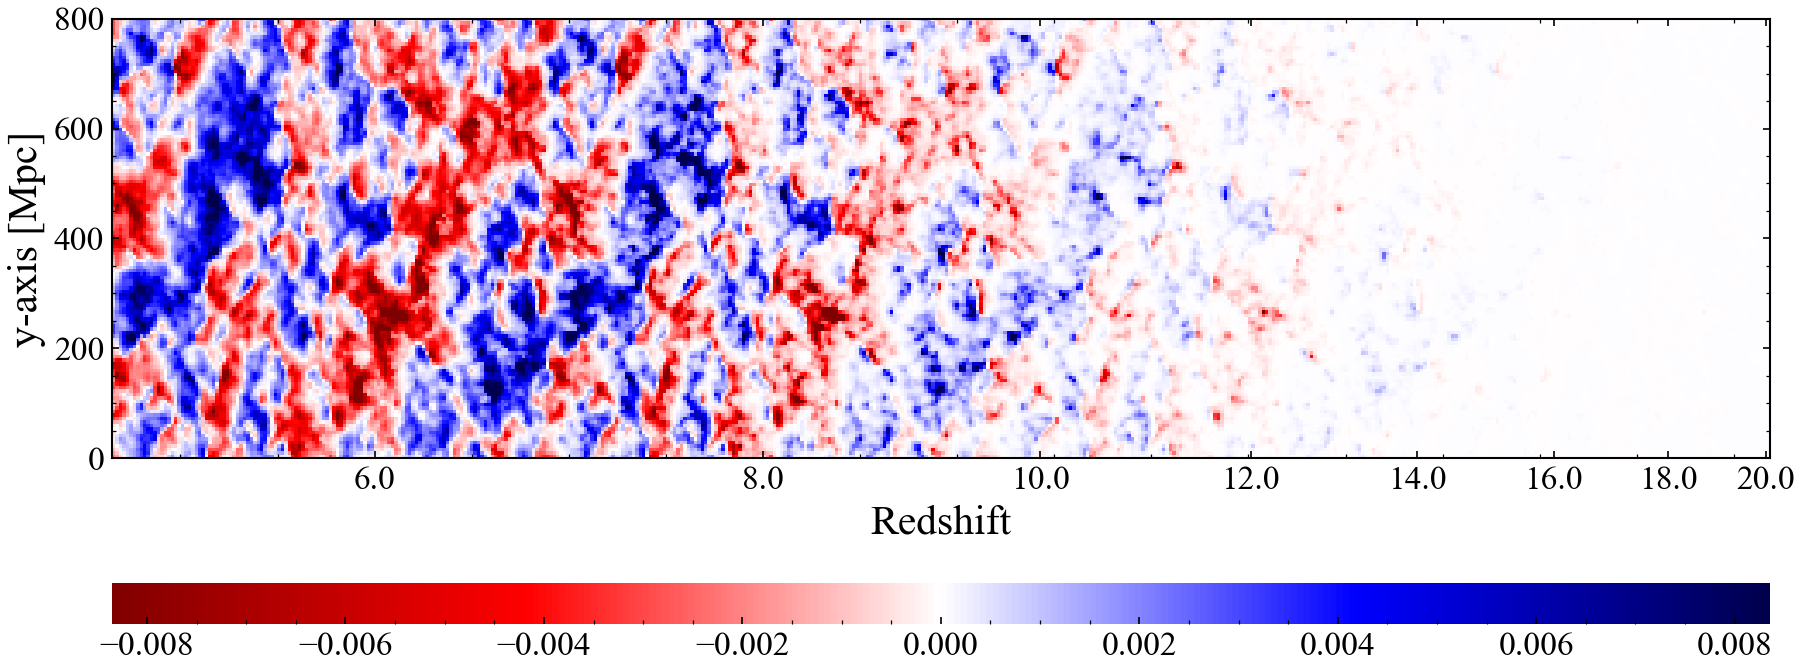

Saved: kSZ_integrand_no_visibility


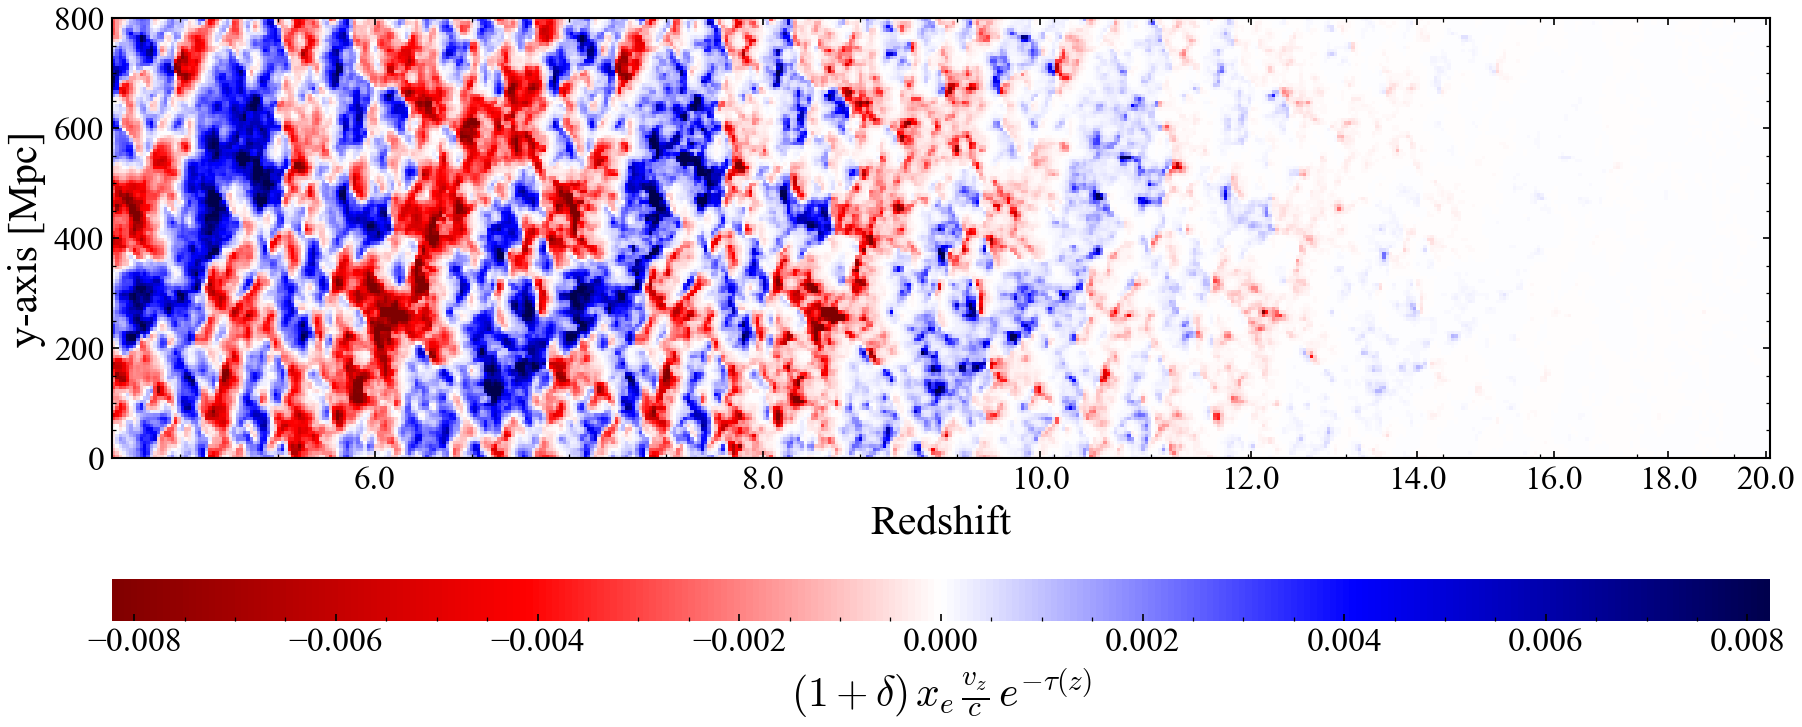

Saved: kSZ_integrand_with_visibility

kSZ INTEGRAND SUMMARY
Effect of visibility function:
  RMS without e^(-τ): 2.1939e-03
  RMS with e^(-τ):    2.1593e-03
  Suppression factor: 0.9842


In [13]:
# =============================================================================
# CELL 5: Compute kSZ Integrand with Visibility Function
# kSZ integrand = (1 + δ) × x_e × v_z / c × e^(-τ(z))
# =============================================================================
# Extract fields (already trimmed to ind_z)
density_1plus = 1 + lightcone.density[:, :, ind_z]  # 1 + δ
x_HII_field = 1 - lightcone.xH_box[:, :, ind_z]     # LOCAL ionized fraction
v_los_Mpc_s = lightcone.velocity[:, :, ind_z]       # Velocity in Mpc/s

# Speed of light in Mpc/s
c_Mpc_s = 299792.458 / 3.08567758e19  # Mpc/s
print(f"Speed of light: c = {c_Mpc_s:.6e} Mpc/s")

# =============================================================================
# Normalize x_e field: x_e = (1-x_HI) / <(1+δ)(1-x_HI)>
# =============================================================================
# Compute density-weighted mean ionized fraction at each redshift slice
x_e_mean_per_slice = np.mean(density_1plus * x_HII_field, axis=(0, 1))  # Shape: (964,)

# Normalized x_e for kSZ integral
x_e_3D = x_HII_field #/ x_e_mean_per_slice[None, None, :]  # Shape: (128, 128, 964)

print(f"\n=== NORMALIZED x_e FIELD ===")
print(f"<(1+δ)·(1-x_HI)> range: [{x_e_mean_per_slice.min():.4f}, {x_e_mean_per_slice.max():.4f}]")
print(f"x_e_3D range: [{x_e_3D.min():.4f}, {x_e_3D.max():.4f}]")
verification_per_slice = np.mean(density_1plus * x_e_3D, axis=(0, 1))
print(f"Verification <(1+δ)·x_e> per slice: min={verification_per_slice.min():.6f}, max={verification_per_slice.max():.6f}")
print(f"All should be ≈1.0")
# =============================================================================
# Interpolate τ(z) onto lightcone redshifts
# =============================================================================

# Ensure tau is dimensionless (strip any units)
tau_dimensionless = np.asarray(tau, dtype=float)

# tau is defined at z_mid (midpoints), need to interpolate to red_axis
# Extend tau to match red_axis length by prepending 0 (at lowest z)
tau_extended = np.concatenate([[0], tau_dimensionless])

# Interpolate tau onto red_axis (trimmed)
tau_at_lightcone = np.interp(red_axis, 
                              np.concatenate([[red_axis[0]], z_mid]), 
                              tau_extended)

print(f"\n=== OPTICAL DEPTH AT LIGHTCONE REDSHIFTS ===")
print(f"τ range: [{tau_at_lightcone.min():.6f}, {tau_at_lightcone.max():.6f}]")
print(f"τ is dimensionless: {type(tau_at_lightcone)}")

# Visibility function e^(-τ)
visibility = np.exp(-tau_at_lightcone)

print(f"\n=== VISIBILITY FUNCTION ===")
print(f"e^(-τ) range: [{visibility.min():.6f}, {visibility.max():.6f}]")

# Broadcast visibility to 3D for multiplication with lightcone fields
# visibility shape: (964,) -> need to reshape to (1, 1, 964) for broadcasting
visibility_3D = visibility[None, None, :]  # Shape (1, 1, 964)

# =============================================================================
# Compute kSZ integrand WITHOUT visibility (for comparison)
# =============================================================================

kSZ_integrand_no_vis = density_1plus * x_e_3D * v_los_Mpc_s / c_Mpc_s

print(f"\n=== kSZ INTEGRAND (no visibility) STATISTICS ===")
print(f"  Mean: {kSZ_integrand_no_vis.mean():.4e}")
print(f"  Std:  {kSZ_integrand_no_vis.std():.4e}")
print(f"  Min:  {kSZ_integrand_no_vis.min():.4e}")
print(f"  Max:  {kSZ_integrand_no_vis.max():.4e}")
print(f"  RMS:  {np.sqrt(np.mean(kSZ_integrand_no_vis**2)):.4e}")

# =============================================================================
# Compute kSZ integrand WITH visibility function
# =============================================================================

kSZ_integrand_with_vis = density_1plus * x_e_3D * v_los_Mpc_s / c_Mpc_s * visibility_3D

print(f"\n=== kSZ INTEGRAND (with visibility) STATISTICS ===")
print(f"  Mean: {kSZ_integrand_with_vis.mean():.4e}")
print(f"  Std:  {kSZ_integrand_with_vis.std():.4e}")
print(f"  Min:  {kSZ_integrand_with_vis.min():.4e}")
print(f"  Max:  {kSZ_integrand_with_vis.max():.4e}")
print(f"  RMS:  {np.sqrt(np.mean(kSZ_integrand_with_vis**2)):.4e}")

# Add to lightcone object for easy access
lightcone.kSZ_integrand_no_vis = kSZ_integrand_no_vis
lightcone.kSZ_integrand = kSZ_integrand_with_vis  # This is the physical one
lightcone.visibility = visibility_3D

# =============================================================================
# kSZ LIGHTCONE PLOTS
# =============================================================================

vmax_no_vis = np.percentile(np.abs(kSZ_integrand_no_vis), 99)
vmax_vis = np.percentile(np.abs(kSZ_integrand_with_vis), 99)

ksz_plots = {
    "kSZ_integrand_no_vis": {
        "title": r"kSZ Integrand (no visibility): $(1+\delta)\,x_e\,v_z/c$",
        "plot_name": "kSZ_integrand_no_visibility",
        "clim": (-vmax_no_vis, vmax_no_vis),
    },
    "kSZ_integrand": {
        "title": r"kSZ Integrand",
        "plot_name": "kSZ_integrand_with_visibility",
        "clim": (-vmax_vis, vmax_vis),
        "cbar_label": r'$(1+\delta)\,x_e\,\frac{v_z}{c}\,e^{-\tau(z)}$',
    },
}

for field, cfg in ksz_plots.items():
    plot_func = make_lightcone_plotter(
        lightcone=lightcone,
        field=field,
        cmap="seismic_r",
        clim=cfg["clim"],
        cbar_label=cfg.get("cbar_label"),
        user_params=user_params,  # ADD THIS LINE
    )

    # Preview PDF style
    with mpl.rc_context(PNG_STYLE):
        fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
        plot_func(ax)
        plt.show()

    # Save PDF + PNG
    save_pdf_png(
        plot_func=plot_func,
        plot_dir=plot_dir,
        plot_name=cfg["plot_name"],
        title=cfg["title"],
    )

    print(f"Saved: {cfg['plot_name']}")


# =============================================================================
# Summary
# =============================================================================

print(f"\n{'='*60}")
print(f"kSZ INTEGRAND SUMMARY")
print(f"{'='*60}")
print(f"Effect of visibility function:")
print(f"  RMS without e^(-τ): {np.sqrt(np.mean(kSZ_integrand_no_vis**2)):.4e}")
print(f"  RMS with e^(-τ):    {np.sqrt(np.mean(kSZ_integrand_with_vis**2)):.4e}")
print(f"  Suppression factor: {np.sqrt(np.mean(kSZ_integrand_with_vis**2)) / np.sqrt(np.mean(kSZ_integrand_no_vis**2)):.4f}")
print(f"{'='*60}")


=== LINE-OF-SIGHT kSZ INTEGRATION ===

=== PHYSICAL CONSTANTS (CGS) ===
c = 3.00e+10 cm/s
σ_T = 6.6525e-25 cm²
n_e0 = 2.0600e-07 cm⁻³
1 Mpc = 3.0857e+24 cm

Prefactor n_e0 × σ_T × c = 4.1112e-21 s⁻¹

=== DISTANCE ELEMENTS ===
ds (stripped units): 6.250000 - 6.250000 Mpc
ds in cm: 1.9286e+25 - 1.9286e+25 cm

Integrand shape: (128, 128, 481)
Integrating over 481 redshift slices
From z = 19.95 to z = 5.00
Integrand type: <class 'numpy.ndarray'>
Sample integrand values: [-1.75903866e-07 -1.04122784e-07 -3.96341274e-08  2.21264415e-08
  8.15797817e-08]

=== kSZ MAP STATISTICS (DIMENSIONLESS) ===
Shape: (128, 128)
Type: <class 'numpy.ndarray'>
Mean: -5.2227e-08
Std:  9.7097e-06
Min:  -4.6915e-05
Max:  4.7659e-05
RMS:  9.7098e-06


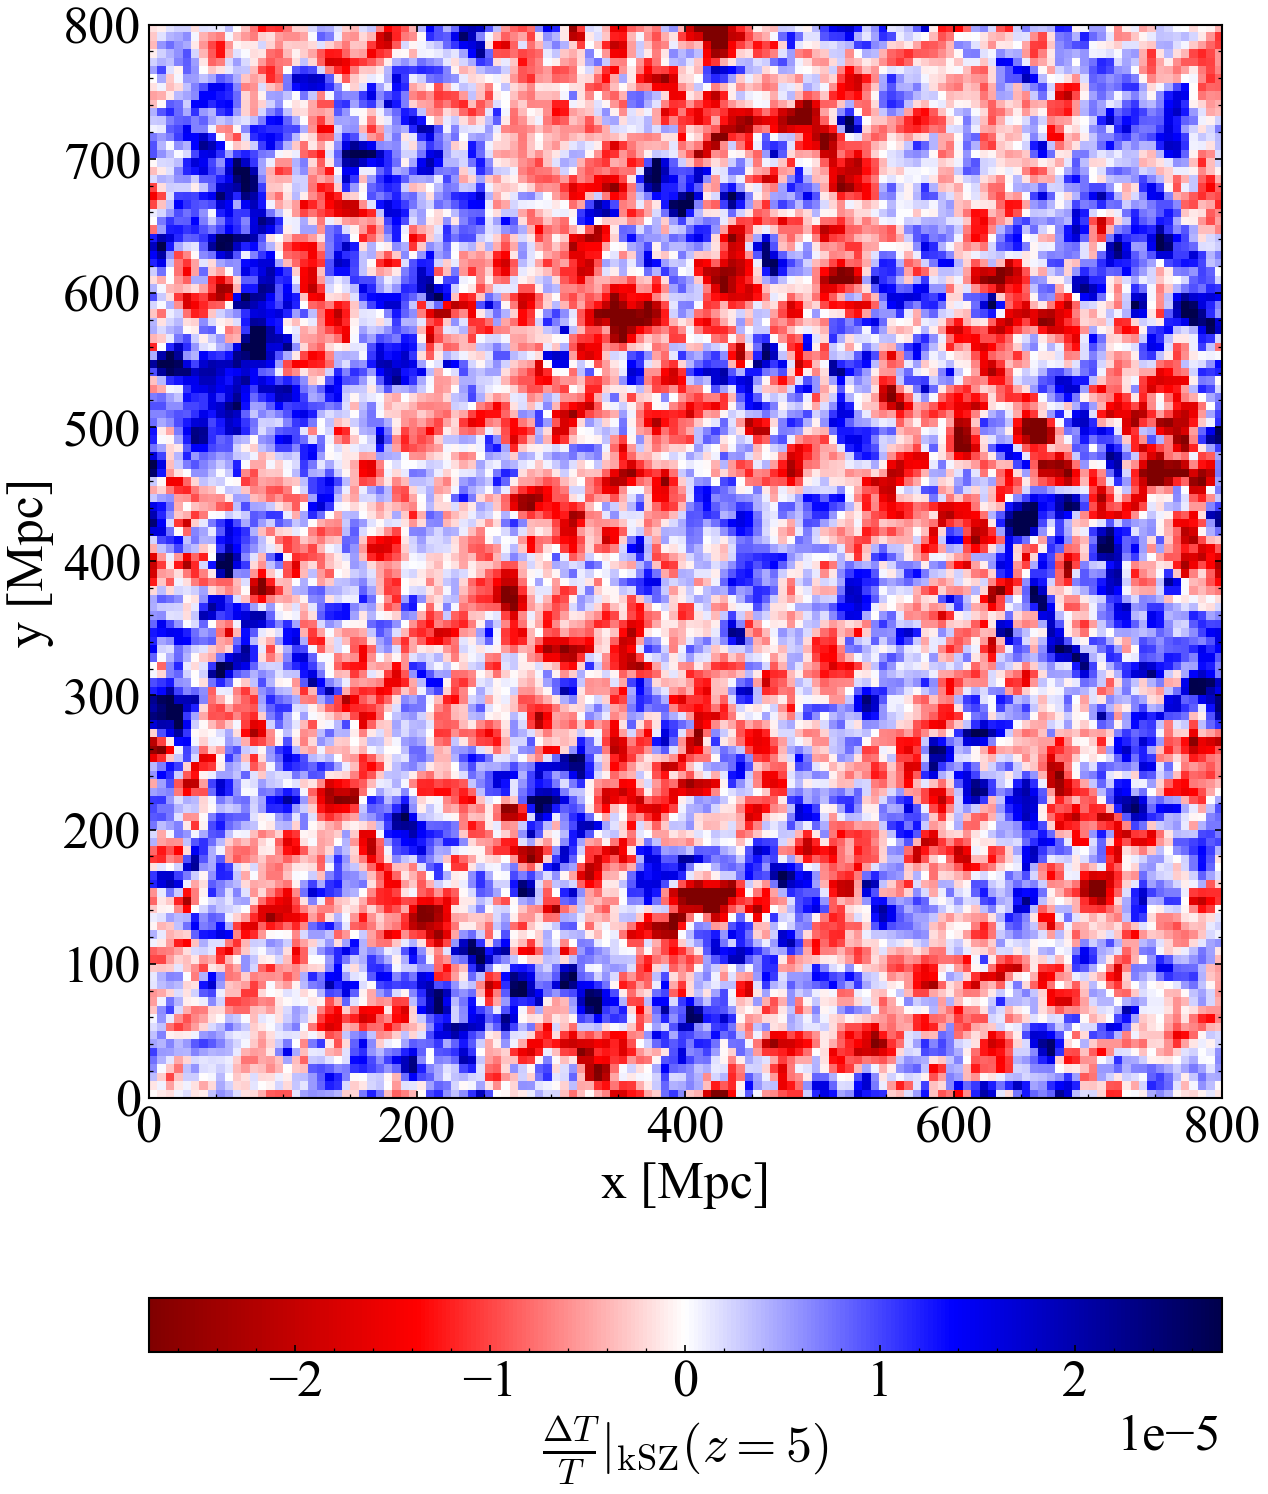

Saved: kSZ_map_z5


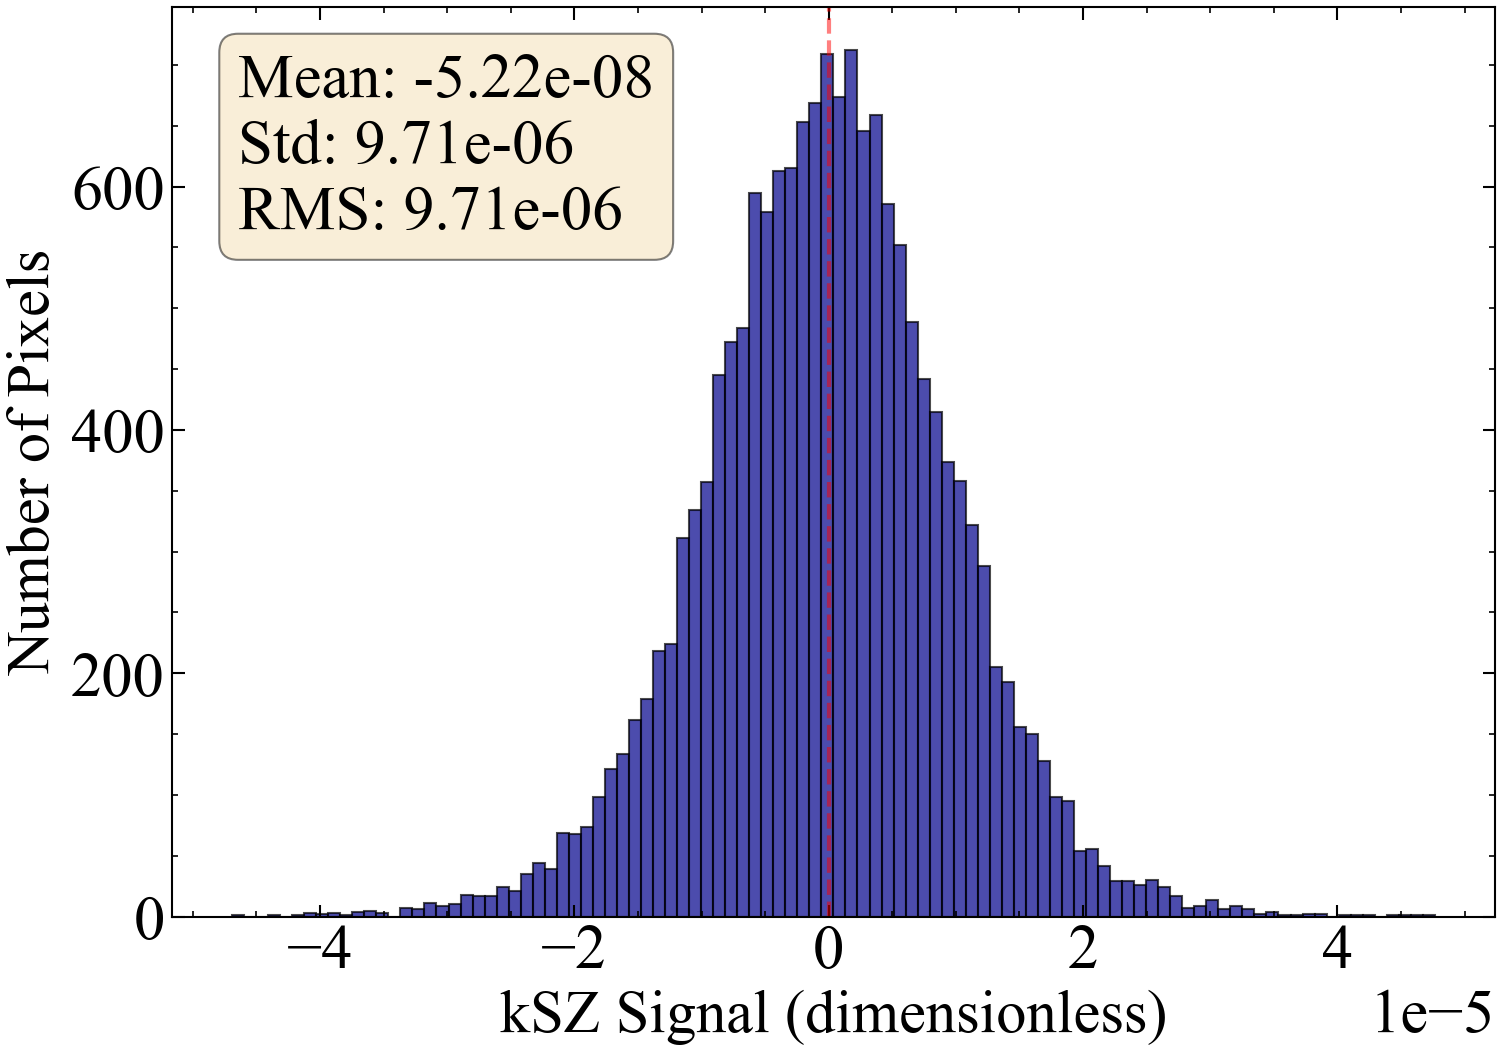

Saved: kSZ_map_histogram

LINE-OF-SIGHT INTEGRATION COMPLETE
Result is DIMENSIONLESS (proper kSZ signal)
Integrated from z = 19.95 → 5.00
Map dimensions: 128 × 128 pixels
Physical size: 800.0 × 800.0 Mpc²
Pixel size: 6.25 Mpc
RMS kSZ signal: 9.7098e-06


In [14]:
# =============================================================================
# CELL 5: Compute Line-of-Sight Integrated kSZ Map (Dimensionless)
# kSZ(z=5) = ∫ n_e0 σ_T (1/a²) (1+δ) x_e v_z/c e^(-τ) ds
# Integration from z=20 to z=5 along line of sight
# =============================================================================

print(f"\n=== LINE-OF-SIGHT kSZ INTEGRATION ===")

# Physical constants in CGS
print(f"\n=== PHYSICAL CONSTANTS (CGS) ===")
c_cm_s = 3.0e10  # cm/s
sigma_T_cm2 = 6.6525e-25  # cm²
n_e0_cm3 = 2.06e-7  # cm⁻³
Mpc_to_cm = 3.0857e24  # cm/Mpc

print(f"c = {c_cm_s:.2e} cm/s")
print(f"σ_T = {sigma_T_cm2:.4e} cm²")
print(f"n_e0 = {n_e0_cm3:.4e} cm⁻³")
print(f"1 Mpc = {Mpc_to_cm:.4e} cm")

# Calculate dimensionless prefactor: n_e0 σ_T c
prefactor_cgs = n_e0_cm3 * sigma_T_cm2 * c_cm_s  # [1/s]
print(f"\nPrefactor n_e0 × σ_T × c = {prefactor_cgs:.4e} s⁻¹")

# Strip units from ds - convert to plain numpy array in Mpc
ds_Mpc = np.asarray(ds.value if hasattr(ds, 'value') else ds, dtype=float)
print(f"\n=== DISTANCE ELEMENTS ===")
print(f"ds (stripped units): {ds_Mpc.min():.6f} - {ds_Mpc.max():.6f} Mpc")

# Convert ds from Mpc to cm
ds_cm = ds_Mpc * Mpc_to_cm  # cm
print(f"ds in cm: {ds_cm.min():.4e} - {ds_cm.max():.4e} cm")

# =============================================================================
# Prepare integrand: (n_e0 σ_T c) × (1/a²) × kSZ_integrand × (ds/c)
# =============================================================================

# Scale factor a = 1/(1+z)
a = 1.0 / (1.0 + red_axis)  # Shape (964,)
a_squared = a**2

# Midpoint kSZ integrand (average between adjacent slices)
kSZ_integrand_mid = 0.5 * (kSZ_integrand_with_vis[:, :, :-1] + 
                            kSZ_integrand_with_vis[:, :, 1:])  # Shape (128, 128, 963)

# Midpoint a²
a_squared_mid = 0.5 * (a_squared[:-1] + a_squared[1:])  # Shape (963,)
a_squared_mid_3D = a_squared_mid[None, None, :]  # Shape (1, 1, 963)

# Full dimensionless integrand for kSZ:
# (n_e0 σ_T c) × (1/a²) × kSZ_integrand × (ds/c)
# [1/s] × [1] × [1] × [s] = [dimensionless]
kSZ_integrand_full = (prefactor_cgs / a_squared_mid_3D) * kSZ_integrand_mid * (ds_cm / c_cm_s)[None, None, :]

print(f"\nIntegrand shape: {kSZ_integrand_full.shape}")
print(f"Integrating over {kSZ_integrand_full.shape[2]} redshift slices")
print(f"From z = {red_axis.max():.2f} to z = {red_axis.min():.2f}")

# Check that integrand is dimensionless
print(f"Integrand type: {type(kSZ_integrand_full)}")
print(f"Sample integrand values: {kSZ_integrand_full[0, 0, :5]}")

# =============================================================================
# Integrate along line of sight (z-axis, axis=2)
# =============================================================================

kSZ_map = np.sum(kSZ_integrand_full, axis=2)  # Shape (128, 128), dimensionless

print(f"\n=== kSZ MAP STATISTICS (DIMENSIONLESS) ===")
print(f"Shape: {kSZ_map.shape}")
print(f"Type: {type(kSZ_map)}")
print(f"Mean: {kSZ_map.mean():.4e}")
print(f"Std:  {kSZ_map.std():.4e}")
print(f"Min:  {kSZ_map.min():.4e}")
print(f"Max:  {kSZ_map.max():.4e}")
print(f"RMS:  {np.sqrt(np.mean(kSZ_map**2)):.4e}")

# Add to lightcone object
lightcone.kSZ_map = kSZ_map

# =============================================================================
# PLOT: kSZ Map at z=5 (final observer slice)
# =============================================================================

def plot_kSZ_map(ax):
    im = ax.imshow(
        kSZ_map.T,
        cmap='seismic_r',
        origin='lower',
        extent=[0, user_params.BOX_LEN, 0, user_params.BOX_LEN],
        aspect='equal'
    )

    # Symmetric colour limits
    vmax_map = np.percentile(np.abs(kSZ_map), 99)
    im.set_clim(-vmax_map, vmax_map)

    # Colorbar
    # Colorbar at the bottom
    fig = ax.figure
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation='horizontal',
        fraction=0.05,
        pad=0.08
    )

    cbar.set_label(r'$\frac{\Delta T}{T}|_{\mathrm{kSZ}}(z=5)$')
    cbar.ax.tick_params(labelsize=25)

    # Labels
    ax.set_xlabel(r'x [Mpc]')
    ax.set_ylabel(r'y [Mpc]')


plot_name = "kSZ_map_z5"

# Preview PDF style
with mpl.rc_context(PNG_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 10), constrained_layout=True)
    plot_kSZ_map(ax)
    plt.show()

# Save PDF + PNG
save_pdf_png(
    plot_func=plot_kSZ_map,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Map at $z=5$ (LOS integrated)"
)

print(f"Saved: {plot_name}")

# =============================================================================
# PLOT: Histogram of kSZ Map Values
# =============================================================================

def plot_kSZ_hist(ax):
    ax.hist(
        kSZ_map.flatten(),
        bins=100,
        color='darkblue',
        alpha=0.7,
        edgecolor='black'
    )

    ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.5)

    ax.set_xlabel('kSZ Signal (dimensionless)')
    ax.set_ylabel('Number of Pixels')

    stats_text = (
        f"Mean: {kSZ_map.mean():.2e}\n"
        f"Std: {kSZ_map.std():.2e}\n"
        f"RMS: {np.sqrt(np.mean(kSZ_map**2)):.2e}"
    )

    ax.text(
        0.05, 0.95,
        stats_text,
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    )


plot_name = "kSZ_map_histogram"

# Preview PDF style
with mpl.rc_context(PDF_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
    plot_kSZ_hist(ax)
    plt.show()

# Save PDF + PNG
save_pdf_png(
    plot_func=plot_kSZ_hist,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title="kSZ Map Pixel Distribution"
)

print(f"Saved: {plot_name}")


# =============================================================================
# Summary
# =============================================================================

print(f"\n{'='*60}")
print(f"LINE-OF-SIGHT INTEGRATION COMPLETE")
print(f"{'='*60}")
print(f"Result is DIMENSIONLESS (proper kSZ signal)")
print(f"Integrated from z = {red_axis.max():.2f} → {red_axis.min():.2f}")
print(f"Map dimensions: {kSZ_map.shape[0]} × {kSZ_map.shape[1]} pixels")
print(f"Physical size: {user_params.BOX_LEN:.1f} × {user_params.BOX_LEN:.1f} Mpc²")
print(f"Pixel size: {user_params.BOX_LEN/kSZ_map.shape[0]:.2f} Mpc")
print(f"RMS kSZ signal: {np.sqrt(np.mean(kSZ_map**2)):.4e}")
print(f"{'='*60}")


COMPUTING kSZ POWER SPECTRUM

=== MAP PROPERTIES ===
Map size: 128 × 128 pixels
Physical size: 800.0 × 800.0 Mpc²
Pixel size: 6.250 Mpc/pixel
Map RMS: 9.7097e-06
Mean subtracted: 1.0588e-22

=== 2D POWER SPECTRUM ===
P(k) range: [1.4505e-38, 8.4569e-07] Mpc²

=== k-SPACE GRID ===
dk (fundamental): 0.007854 Mpc⁻¹
k range: [0.000000, 0.710861] Mpc⁻¹

=== AZIMUTHALLY AVERAGED P(k) ===
Valid k bins: 29 out of 34
P(k) range: [4.2349e-11, 2.0402e-07] Mpc²

=== CONVERSION TO ℓ SPACE ===
Reionization redshift: z = 5.0
Comoving distance: χ = 7800.0 Mpc
ℓ range: 98 to 6996


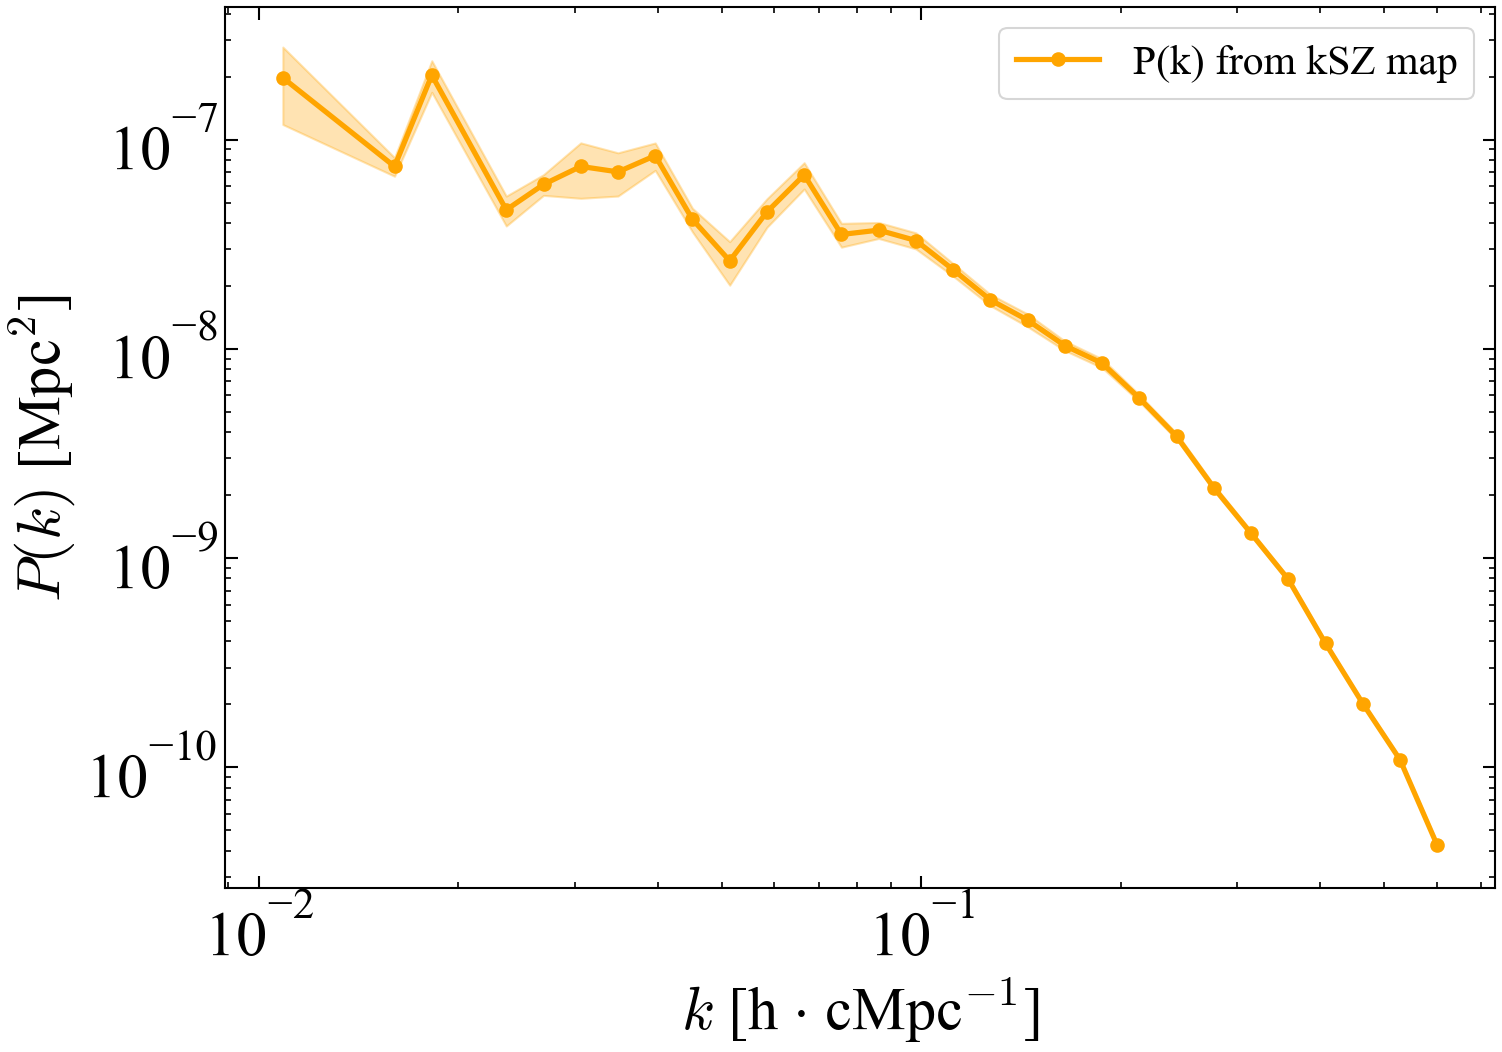

Saved: kSZ_Pk


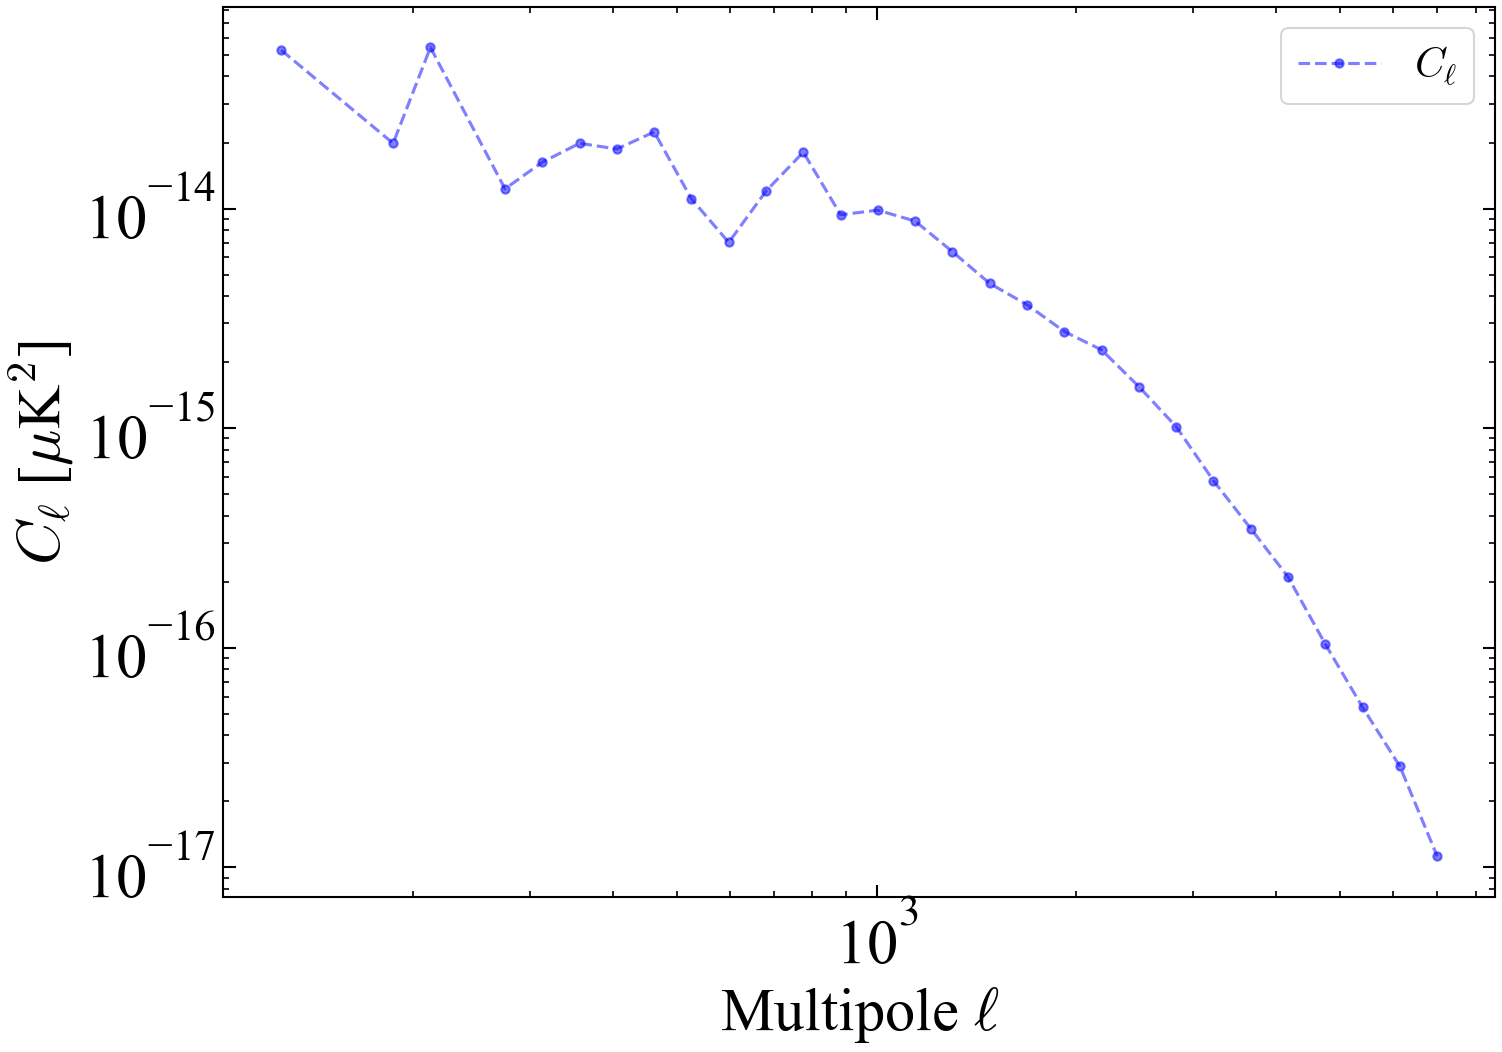

Saved: kSZ_Cl_corrected

POWER SPECTRUM SUMMARY

NOTE: This uses flat-sky approximation


In [23]:
# =============================================================================
# CELL 6: Compute kSZ Power Spectrum - P(k), C_ℓ, and D_ℓ
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

print(f"\n{'='*60}")
print(f"COMPUTING kSZ POWER SPECTRUM")
print(f"{'='*60}")

# =============================================================================
# 1. Settings and Map Info
# =============================================================================

# Map info
npix_side = kSZ_map.shape[0]  # Should be 128
box_size_Mpc = user_params.BOX_LEN  # Physical size in Mpc
pix_size_Mpc = box_size_Mpc / npix_side  # Mpc per pixel

print(f"\n=== MAP PROPERTIES ===")
print(f"Map size: {npix_side} × {npix_side} pixels")
print(f"Physical size: {box_size_Mpc:.1f} × {box_size_Mpc:.1f} Mpc²")
print(f"Pixel size: {pix_size_Mpc:.3f} Mpc/pixel")
print(f"Map RMS: {np.std(kSZ_map):.4e}")

# Remove mean (important for power spectrum!)
kSZ_map_centered = kSZ_map - np.mean(kSZ_map)
print(f"Mean subtracted: {np.mean(kSZ_map_centered):.4e}")

# =============================================================================
# 2. Compute 2D Power Spectrum P(k) in [Mpc²]
# =============================================================================

# FFT and shift to center
fft_map = np.fft.fft2(kSZ_map_centered)
fft_map_shifted = np.fft.fftshift(fft_map)

# Pixel area in physical units
pix_area = pix_size_Mpc**2  # Mpc²

# 2D power spectrum: P(k) in [Mpc²]
#ps2d = np.abs(fft_map_shifted)**2 * pix_area / (npix_side**4)
# 2D power spectrum: P(k) in [Mpc²]
ps2d = (pix_size_Mpc / npix_side)**2 * np.abs(fft_map_shifted)**2

print(f"\n=== 2D POWER SPECTRUM ===")
print(f"P(k) range: [{ps2d.min():.4e}, {ps2d.max():.4e}] Mpc²")

# =============================================================================
# 3. k-space grid [Mpc⁻¹]
# =============================================================================

# Fundamental frequency
dk = 2 * np.pi / (npix_side * pix_size_Mpc)  # Mpc⁻¹

# k-space coordinates
kx = np.fft.fftshift(np.fft.fftfreq(npix_side)) * npix_side * dk
ky = np.fft.fftshift(np.fft.fftfreq(npix_side)) * npix_side * dk
kgrid = np.sqrt(kx[:, None]**2 + ky[None, :]**2)

print(f"\n=== k-SPACE GRID ===")
print(f"dk (fundamental): {dk:.6f} Mpc⁻¹")
print(f"k range: [{kgrid.min():.6f}, {kgrid.max():.6f}] Mpc⁻¹")

# =============================================================================
# 4. Azimuthally Averaged P(k)
# =============================================================================

# Define k bins (logarithmic spacing)
k_bins = np.logspace(np.log10(dk), np.log10(kgrid.max()*0.9), 35)
k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])
P1d = np.zeros(len(k_centers))
P1d_err = np.zeros(len(k_centers))

for i in range(len(k_centers)):
    mask = (kgrid >= k_bins[i]) & (kgrid < k_bins[i+1])
    if np.sum(mask) > 0:
        values = ps2d[mask]
        P1d[i] = np.mean(values)
        P1d_err[i] = np.std(values) / np.sqrt(np.sum(mask))
    else:
        P1d[i] = np.nan

print(f"\n=== AZIMUTHALLY AVERAGED P(k) ===")
valid_bins = np.sum(~np.isnan(P1d) & (P1d > 0))
print(f"Valid k bins: {valid_bins} out of {len(k_centers)}")
print(f"P(k) range: [{np.nanmin(P1d[P1d>0]):.4e}, {np.nanmax(P1d):.4e}] Mpc²")

# =============================================================================
# 5. Convert to ℓ space (flat-sky approximation for kSZ)
# =============================================================================

# For kSZ, we need the COMOVING distance to the reionization era
# At z=5, comoving distance (not angular diameter distance!)
z_reion = 5.0

# Comoving distance to z=5 in Planck cosmology: χ ≈ 7800 Mpc
chi_comoving_Mpc = 7800  # This is the light travel distance (comoving)

# Alternative: If you have angular diameter distance D_A
D_A_physical = 1300  # Physical angular diameter distance at z=5
chi_comoving_Mpc = D_A_physical * (1 + z_reion)  # = 1300 × 6 = 7800 Mpc

print(f"\n=== CONVERSION TO ℓ SPACE ===")
print(f"Reionization redshift: z = {z_reion}")
print(f"Comoving distance: χ = {chi_comoving_Mpc:.1f} Mpc")

# Flat-sky approximation: ℓ = k × χ
ell_from_k = k_centers * chi_comoving_Mpc/0.67

# Power spectrum conversion: C_ℓ = P(k) / χ²
Cl_kSZ_DA = P1d*0.67**2 / D_A_physical**2 
#Cl_kSZ_comov = P1d / chi_comoving_Mpc**2
# Convert to D_ℓ = ℓ(ℓ+1) C_ℓ / (2π) in μK²
Dl_kSZ_muK2_DA = ell_from_k * (ell_from_k + 1) * Cl_kSZ_DA / (2 * np.pi)
#Dl_kSZ_muK2_comov = ell_from_k * (ell_from_k + 1) * Cl_kSZ_comov / (2 * np.pi)

print(f"ℓ range: {ell_from_k.min():.0f} to {ell_from_k.max():.0f}")
#print(f"Peak D_ℓ: {Dl_kSZ_muK2.max():.2e} μK²")


# =============================================================================
# PLOT 1: P(k) - 3D Matter Power Spectrum
# =============================================================================

def plot_Pk(ax):
    valid = ~np.isnan(P1d) & (P1d > 0)

    ax.loglog(
        k_centers[valid], P1d[valid],
        'o-', color='orange',
        linewidth=2.5, markersize=6,
        label='P(k) from kSZ map'
    )

    ax.fill_between(
        k_centers[valid],
        (P1d - P1d_err)[valid],
        (P1d + P1d_err)[valid],
        alpha=0.3, color='orange'
    )

    ax.set_xlabel(r'$k$ [h $\cdot$ cMpc$^{-1}$]')
    ax.set_ylabel(r'$P(k)$ [Mpc$^{2}$]')
    ax.legend(loc='best')


plot_name = "kSZ_Pk"

with mpl.rc_context(PDF_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
    plot_Pk(ax)
    plt.show()

save_pdf_png(
    plot_func=plot_Pk,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title="kSZ Power Spectrum $P(k)$"
)

print(f"Saved: {plot_name}")

# =============================================================================
# PLOT 2: C_ℓ - Angular Power Spectrum
# =============================================================================

def plot_Cl(ax):
    valid = ~np.isnan(Cl_kSZ_DA) & (Cl_kSZ_DA > 0) & (ell_from_k > 10)

    ax.loglog(
        ell_from_k[valid], Cl_kSZ_DA[valid],
        'o--', color='blue',
        alpha=0.5, linewidth=1.5, markersize=4,
        label=r'$C_\ell$'
    )

    ax.set_xlabel(r'Multipole $\ell$')
    ax.set_ylabel(r'$C_\ell$ [$\mu$K$^2$]')
    ax.legend(loc='best')


plot_name = "kSZ_Cl_corrected"

with mpl.rc_context(PDF_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
    plot_Cl(ax)
    plt.show()

save_pdf_png(
    plot_func=plot_Cl,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Angular Power Spectrum $C_\ell$"
)

print(f"Saved: {plot_name}")


# =============================================================================
# Summary
# =============================================================================

print(f"\n{'='*60}")
print(f"POWER SPECTRUM SUMMARY")
print(f"{'='*60}")
#print(f"P(k) computed in range: k = {k_centers[valid].min():.4f} - {k_centers[valid].max():.4f} Mpc⁻¹")
#print(f"C_ℓ computed in range: ℓ = {ell_from_k[valid].min():.1f} - {ell_from_k[valid].max():.1f}")
print(f"\nNOTE: This uses flat-sky approximation")
#print(f"Conversion: ℓ ≈ k × D_A where D_A = {D_A_Mpc:.1f} Mpc at z={z_obs}")
print(f"{'='*60}")

Parseval check — map variance: 9.4278e-11,  FFT: 9.4278e-11,  ratio: 1.0000


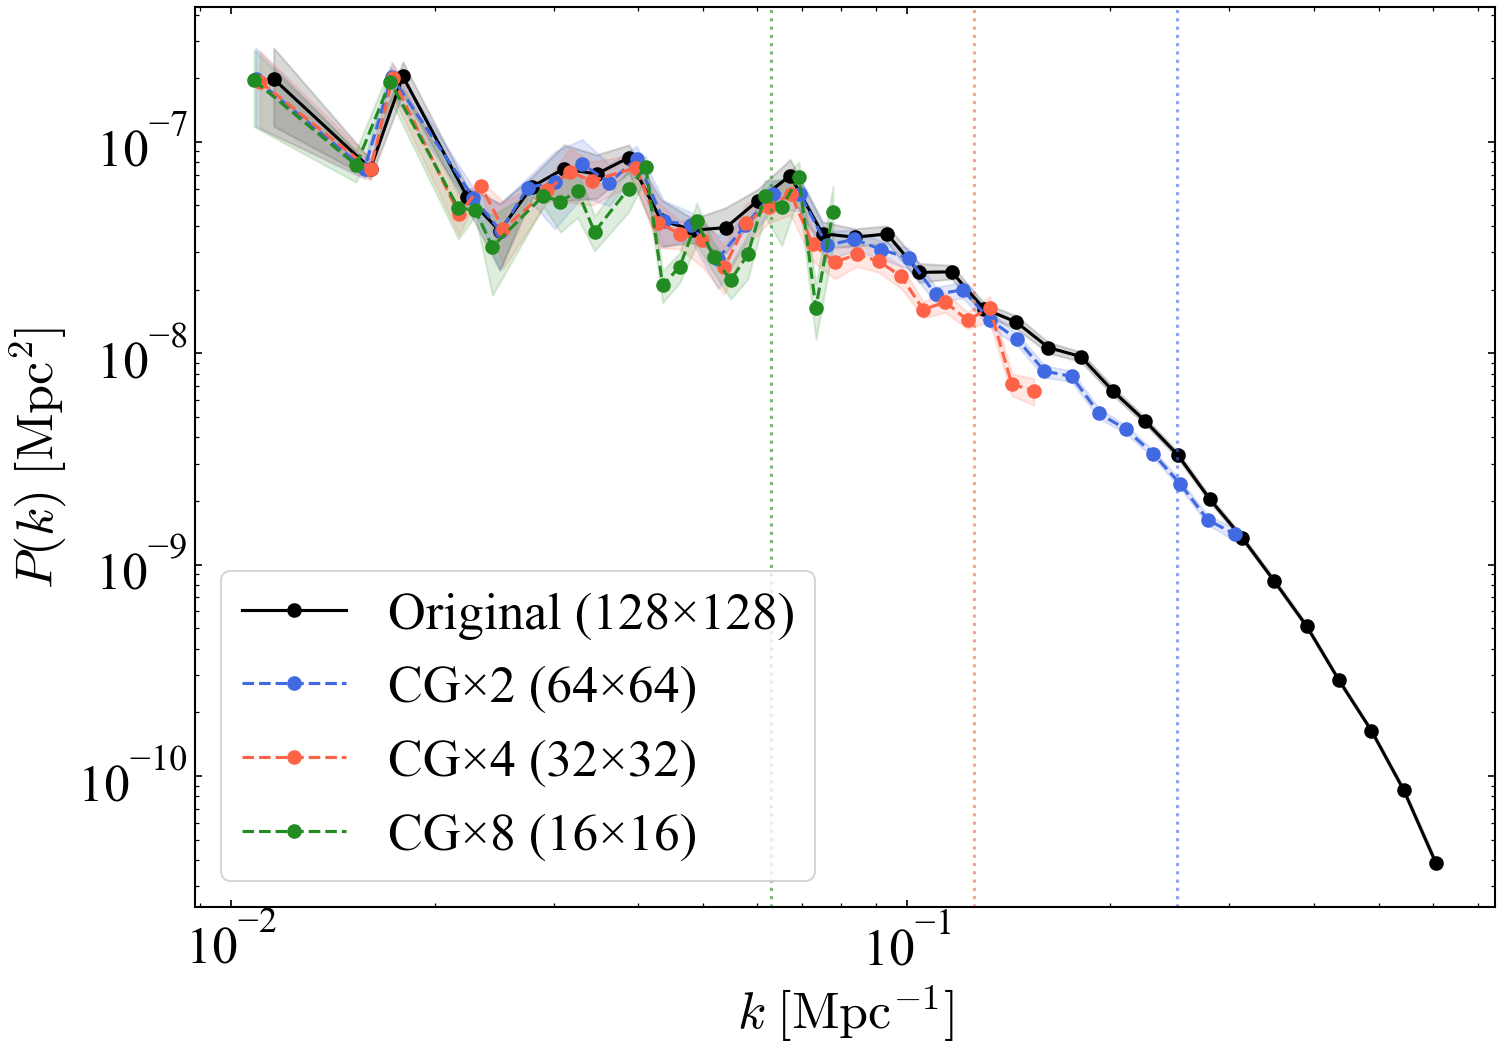

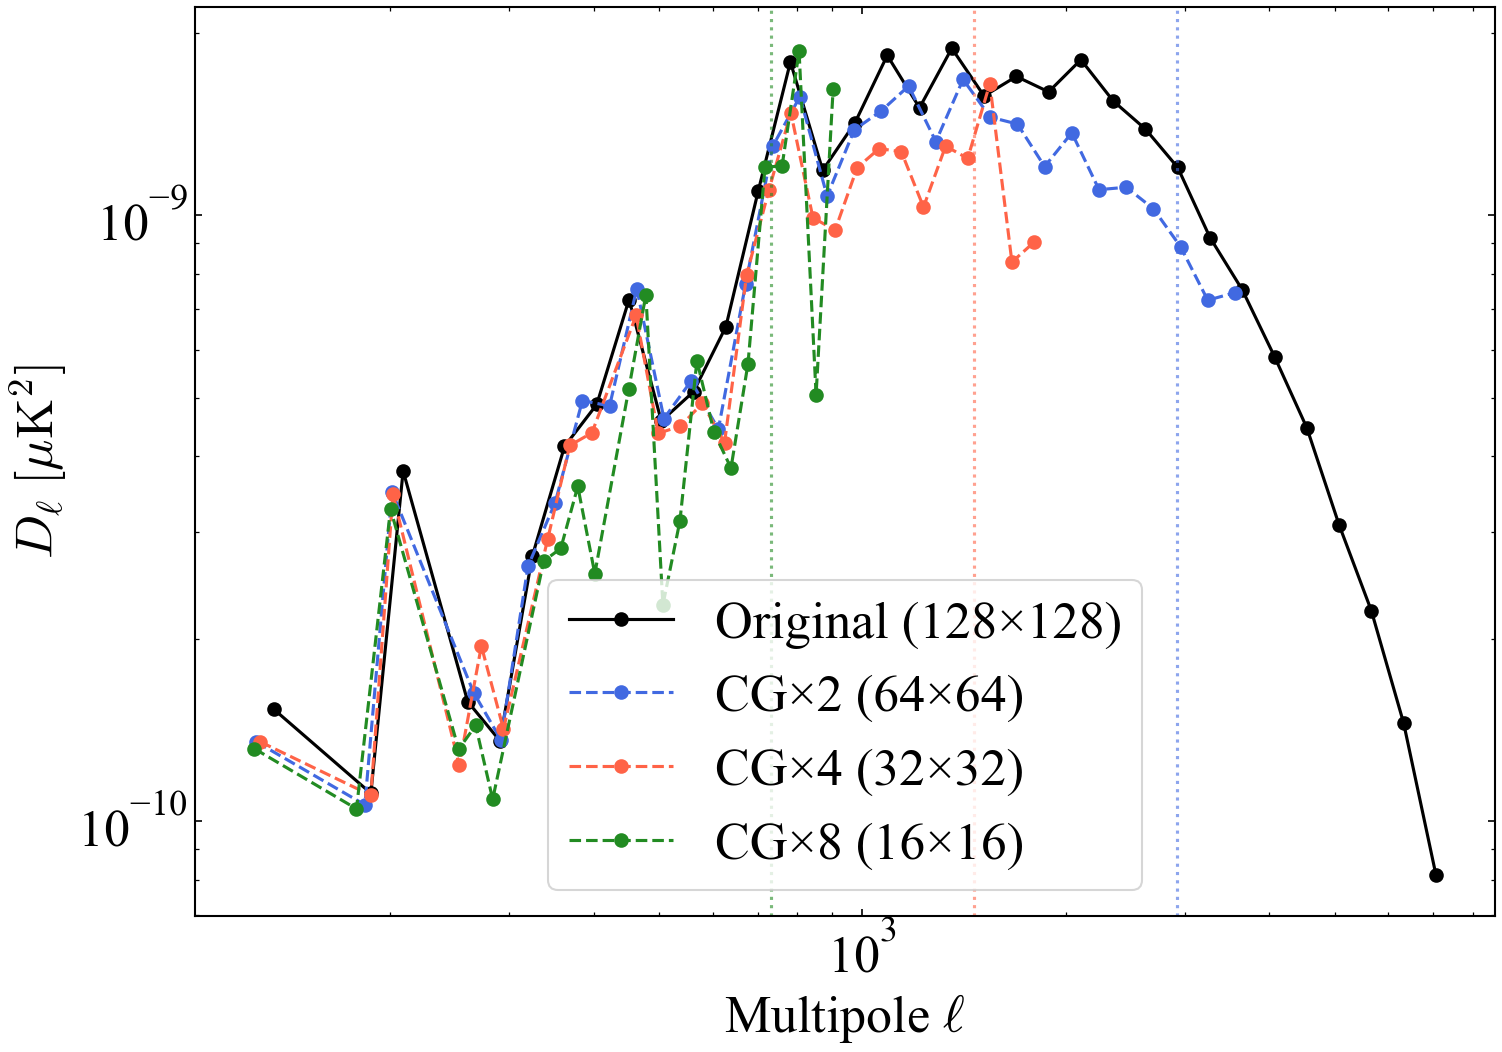

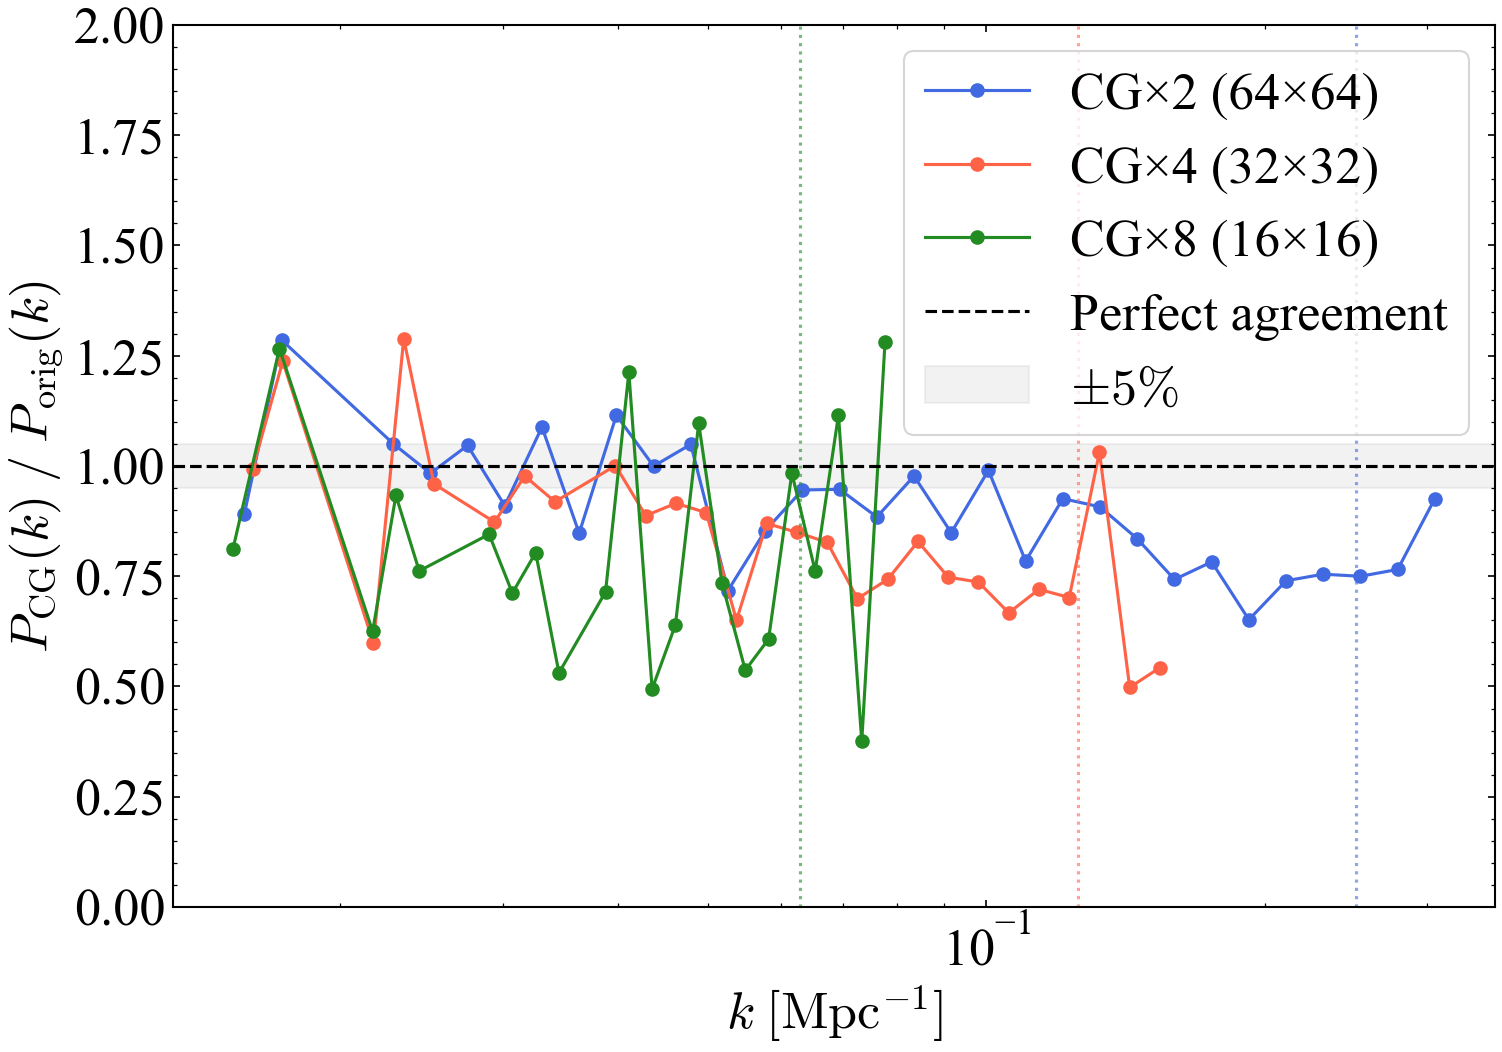

In [28]:
# =============================================================================
# CELL 6b: Normalization Validation via Coarse-Graining
# =============================================================================
# Paste this after Cell 6. Requires: kSZ_map, user_params, plot_dir,
#   PDF_STYLE, PNG_STYLE, save_pdf_png (already defined in your notebook).
# =============================================================================

import numpy as np

# ── core functions ────────────────────────────────────────────────────────────

def compute_ps2d(mp, pix_size_Mpc):
    """
    2D power spectrum. Correct normalization:
        P(k) [Mpc²] = (pix_size / N)² * |FFT(map - mean)|²
    This is invariant under coarse-graining (box_size fixed, N and pix_size
    change together), so CG and original curves should overlap.
    """
    N = mp.shape[0]
    mp_centered = mp - np.mean(mp)
    fft_shifted = np.fft.fftshift(np.fft.fft2(mp_centered))
    ps2d = (pix_size_Mpc / N)**2 * np.abs(fft_shifted)**2
    return ps2d


def compute_kgrid(N, pix_size_Mpc):
    dk = 2 * np.pi / (N * pix_size_Mpc)
    kx = np.fft.fftshift(np.fft.fftfreq(N)) * N * dk
    ky = np.fft.fftshift(np.fft.fftfreq(N)) * N * dk
    kgrid = np.sqrt(kx[:, None]**2 + ky[None, :]**2)
    return kgrid, dk


def azimuthal_average(ps2d, kgrid, dk_fund, n_bins=35):
    k_bins = np.logspace(np.log10(dk_fund), np.log10(kgrid.max() * 0.9), n_bins + 1)
    k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])
    P1d     = np.full(n_bins, np.nan)
    P1d_err = np.full(n_bins, np.nan)
    for i in range(n_bins):
        mask = (kgrid >= k_bins[i]) & (kgrid < k_bins[i + 1])
        if mask.sum() > 0:
            vals = ps2d[mask]
            P1d[i]     = vals.mean()
            P1d_err[i] = vals.std() / np.sqrt(mask.sum())
    return k_centers, P1d, P1d_err


def coarse_grain(mp, factor):
    N = mp.shape[0]
    assert N % factor == 0, f"Map size {N} not divisible by factor {factor}"
    Nn = N // factor
    return mp.reshape(Nn, factor, Nn, factor).mean(axis=(1, 3))


def compute_Cl_Dl(k_centers, P1d, D_A_physical=1300, h=0.67, z_reion=5.0):
    chi = D_A_physical * (1 + z_reion)
    ell = k_centers * chi / h
    Cl  = P1d * h**2 / D_A_physical**2
    Dl  = ell * (ell + 1) * Cl / (2 * np.pi)
    return ell, Cl, Dl


def build_results(mp, pix_size_Mpc, label, n_bins=40,
                  D_A_physical=1300, h=0.67):
    N = mp.shape[0]
    ps2d          = compute_ps2d(mp, pix_size_Mpc)
    kgrid, dk     = compute_kgrid(N, pix_size_Mpc)
    k, P1d, P1d_err = azimuthal_average(ps2d, kgrid, dk, n_bins=n_bins)
    ell, Cl, Dl   = compute_Cl_Dl(k, P1d, D_A_physical, h)
    return dict(k=k, P1d=P1d, P1d_err=P1d_err,
                ell=ell, Cl=Cl, Dl=Dl,
                k_nyq=np.pi / pix_size_Mpc,
                pix_size=pix_size_Mpc, N=N, label=label)


# ── build all results ─────────────────────────────────────────────────────────

N            = kSZ_map.shape[0]
pix_size_Mpc = user_params.BOX_LEN / N
D_A_physical = 1300   # Mpc at z=5
h            = 0.67
coarse_factors = (2, 4, 8)
n_bins       = 40

results = {}
results['original'] = build_results(kSZ_map, pix_size_Mpc,
                                     f'Original ({N}×{N})',
                                     n_bins, D_A_physical, h)

for factor in coarse_factors:
    mp_cg  = coarse_grain(kSZ_map, factor)
    pix_cg = pix_size_Mpc * factor
    Nn     = N // factor
    results[f'cg_{factor}'] = build_results(mp_cg, pix_cg,
                                             f'CG×{factor} ({Nn}×{Nn})',
                                             n_bins, D_A_physical, h)

# Parseval check
fft2 = np.fft.fft2(kSZ_map - np.mean(kSZ_map))
parseval_ps  = np.mean(np.abs(fft2)**2) / N**2
map_var      = np.var(kSZ_map)
print(f"Parseval check — map variance: {map_var:.4e},  FFT: {parseval_ps:.4e},  ratio: {parseval_ps/map_var:.4f}")

# ── plot helpers ──────────────────────────────────────────────────────────────

COLORS = ['black', 'royalblue', 'tomato', 'forestgreen', 'purple']

def _add_nyquist(ax, res, col, x_is_ell=False, D_A_physical=1300, h=0.67, z_reion=5.0):
    if x_is_ell:
        chi     = D_A_physical * (1 + z_reion)
        x_nyq   = res['k_nyq'] * chi / h
    else:
        x_nyq   = res['k_nyq']
    ax.axvline(x_nyq, color=col, linestyle=':', alpha=0.6, linewidth=1.5)


# ── PLOT 1: P(k) ─────────────────────────────────────────────────────────────

def plot_Pk_validation(ax):
    for i, (key, res) in enumerate(results.items()):
        valid = ~np.isnan(res['P1d']) & (res['P1d'] > 0)
        col   = COLORS[i]
        ls    = '-' if i == 0 else '--'
        ax.loglog(res['k'][valid], res['P1d'][valid],
                  linestyle=ls, marker='o', color=col,
                  label=res['label'])
        ax.fill_between(res['k'][valid],
                        (res['P1d'] - res['P1d_err'])[valid],
                        (res['P1d'] + res['P1d_err'])[valid],
                        alpha=0.15, color=col)
        if key != 'original':
            _add_nyquist(ax, res, col, x_is_ell=False)
    ax.set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$')
    ax.set_ylabel(r'$P(k)\;[\mathrm{Mpc}^{2}]$')
    ax.legend()

save_pdf_png(plot_Pk_validation, plot_dir,
             'kSZ_coarsegrain_Pk',
             title=r'Normalization check: $P(k)$ — curves must overlap')

with mpl.rc_context(PNG_STYLE):
    fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
    plot_Pk_validation(ax)
    plt.show()


# ── PLOT 2: D_ℓ ──────────────────────────────────────────────────────────────

def plot_Dl_validation(ax):
    for i, (key, res) in enumerate(results.items()):
        valid = (~np.isnan(res['Dl']) & (res['Dl'] > 0) & (res['ell'] > 10))
        col   = COLORS[i]
        ls    = '-' if i == 0 else '--'
        ax.loglog(res['ell'][valid], res['Dl'][valid],
                  linestyle=ls, marker='o', color=col,
                  label=res['label'])
        if key != 'original':
            _add_nyquist(ax, res, col, x_is_ell=True,
                         D_A_physical=D_A_physical, h=h)
    ax.set_xlabel(r'Multipole $\ell$')
    ax.set_ylabel(r'$D_\ell\;[\mu\mathrm{K}^2]$')
    ax.legend()

save_pdf_png(plot_Dl_validation, plot_dir,
             'kSZ_coarsegrain_Dl',
             title=r'Normalization check: $D_\ell$ — curves must overlap')

with mpl.rc_context(PNG_STYLE):
    fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
    plot_Dl_validation(ax)
    plt.show()


# ── PLOT 3: ratio P_CG / P_orig ──────────────────────────────────────────────

orig = results['original']
valid_or = ~np.isnan(orig['P1d']) & (orig['P1d'] > 0)

def plot_ratio(ax):
    for i, (key, res) in enumerate(results.items()):
        if key == 'original':
            continue
        col      = COLORS[i]
        valid_cg = ~np.isnan(res['P1d']) & (res['P1d'] > 0)
        P_interp = np.interp(res['k'][valid_cg],
                             orig['k'][valid_or], orig['P1d'][valid_or],
                             left=np.nan, right=np.nan)
        ratio = res['P1d'][valid_cg] / P_interp
        ax.semilogx(res['k'][valid_cg], ratio,
                    'o-', color=col, label=res['label'])
        _add_nyquist(ax, res, col, x_is_ell=False)
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5,
               label='Perfect agreement')
    ax.axhspan(0.95, 1.05, alpha=0.1, color='gray', label=r'$\pm5\%$')
    ax.set_xlabel(r'$k\;[\mathrm{Mpc}^{-1}]$')
    ax.set_ylabel(r'$P_{\mathrm{CG}}(k)\;/\;P_{\mathrm{orig}}(k)$')
    ax.set_ylim(0, 2)
    ax.legend()

save_pdf_png(plot_ratio, plot_dir,
             'kSZ_coarsegrain_ratio',
             title=r'Ratio $P_{\rm CG}/P_{\rm orig}$ — should be $\approx 1$ below $k_{\rm Nyq}$')

with mpl.rc_context(PNG_STYLE):
    fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
    plot_ratio(ax)
    plt.show()

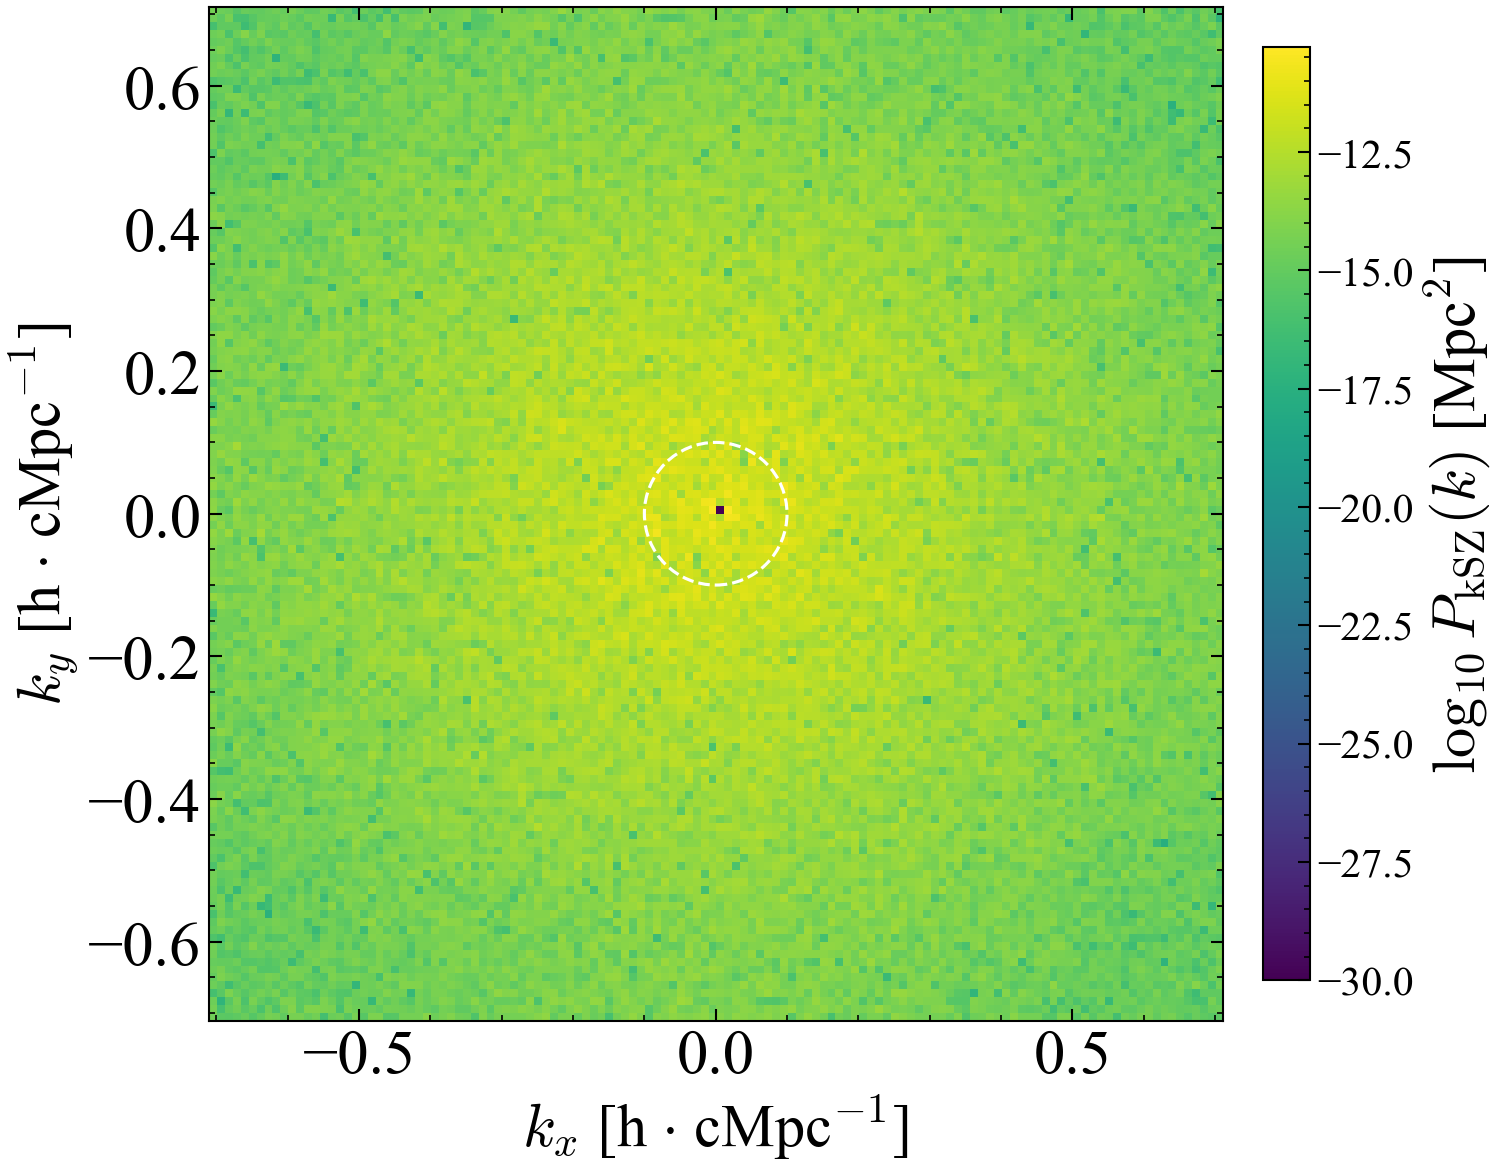

Saved: kSZ_2D_power_map


In [16]:
#== ===========================================================================#
# EXTRA PLOT: 2D Power Spectrum P(kx, ky)
#== ===========================================================================#

def plot_kSZ_2D_power(ax):
    # Log-scale power for visualisation
    ps2d_log = np.log10(ps2d + 1e-30)

    # k-space extent
    k_max = kgrid.max()

    im = ax.imshow(
        ps2d_log.T,
        origin='lower',
        cmap='viridis',
        extent=[-k_max, k_max, -k_max, k_max],
        aspect='equal'
    )

    # Colorbar
    fig = ax.figure
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\log_{10} P_{\rm kSZ}(k)$ [Mpc$^2$]')
    cbar.ax.tick_params(labelsize=20)

    # Axes
    ax.set_xlabel(r'$k_x$ [h $\cdot$ cMpc$^{-1}$]')
    ax.set_ylabel(r'$k_y$ [h $\cdot$ cMpc$^{-1}$]')

    # Optional reference scale (e.g. k = 0.1 Mpc⁻¹)
    circle = plt.Circle(
        (0, 0), 0.1,
        color='white',
        fill=False,
        linestyle='--',
        linewidth=1.5
    )
    ax.add_patch(circle)

plot_name = "kSZ_2D_power_map"

with mpl.rc_context(PDF_STYLE):
    fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
    plot_kSZ_2D_power(ax)
    plt.show()

save_pdf_png(
    plot_func=plot_kSZ_2D_power,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ 2D Power Spectrum in $k$-space"
)

print(f"Saved: {plot_name}")



=== CMB TEMPERATURE ===
T_CMB(z=0) = 2.725 K
T_CMB(z=5) = 2.725 K = 2725000.00 μK

=== D_ℓ CONVERSION ===
Conversion factor: T_CMB²(z=5) = 7.4256e+12 μK²


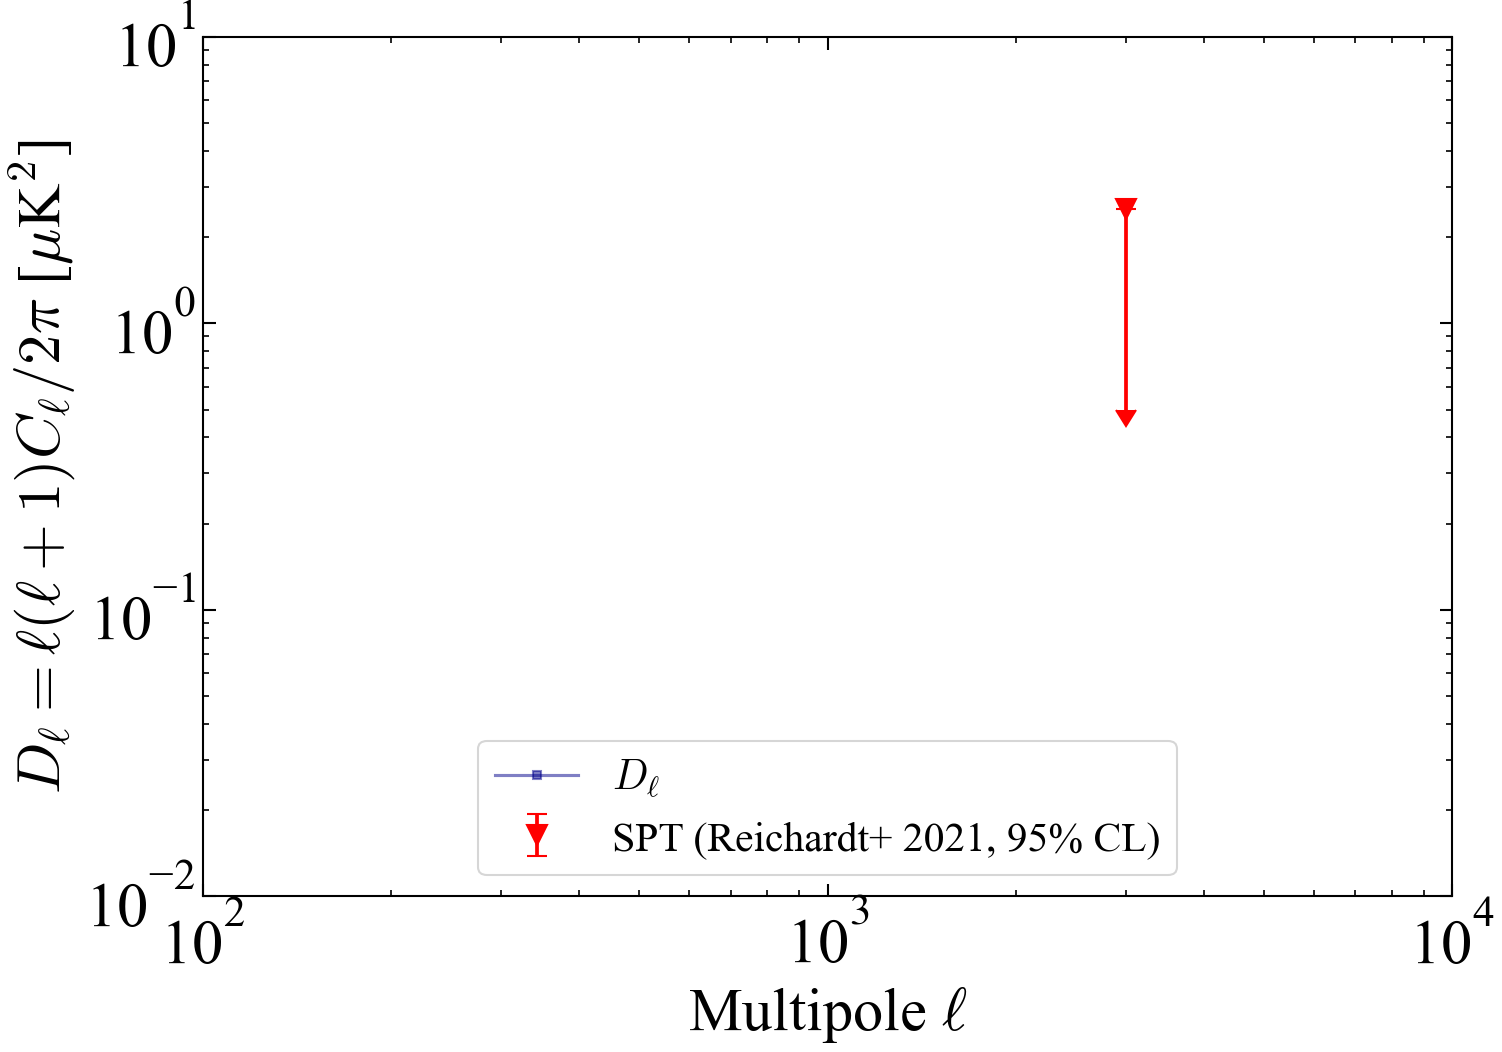

Saved: kSZ_Dl_muK2


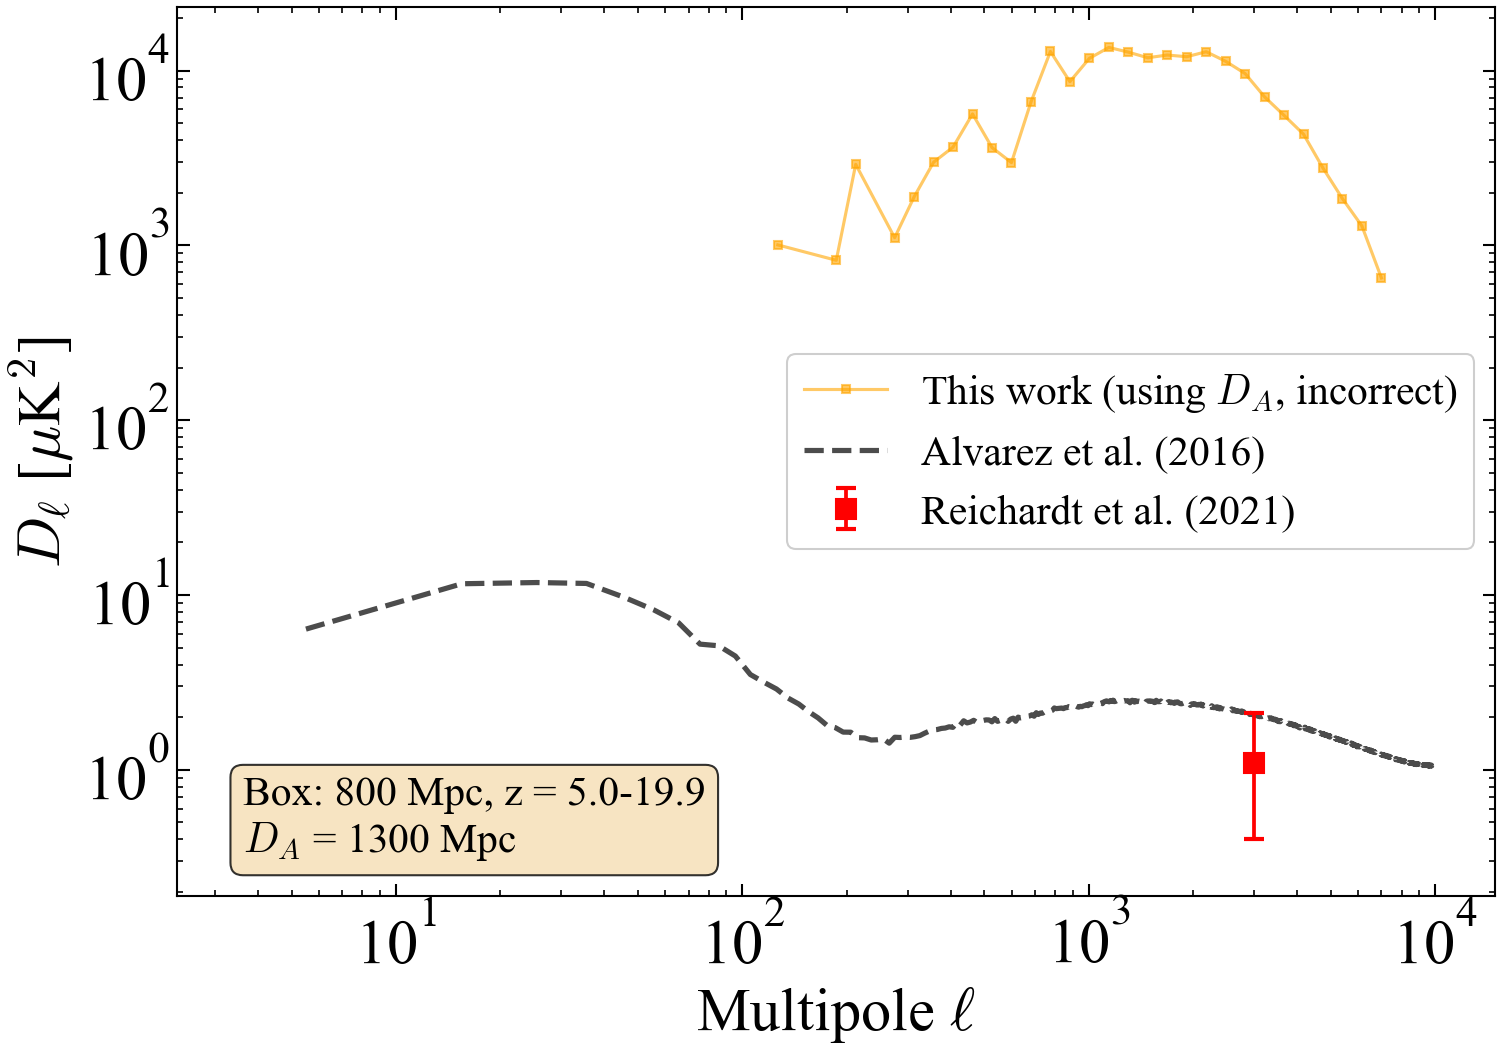

Saved: kSZ_Dl_muK2_with_observations


In [24]:
# =============================================================================
# 6. Convert D_ℓ to μK² using CMB temperature
# =============================================================================

# CMB temperature today
T_CMB_0_K = 2.725  # K

# CMB temperature at z=5
z_obs = 5.0
T_CMB_z5_K = T_CMB_0_K #* (1 + z_obs)  # K

# Convert to μK
T_CMB_z5_uK = T_CMB_z5_K * 1e6  # μK

print(f"\n=== CMB TEMPERATURE ===")
print(f"T_CMB(z=0) = {T_CMB_0_K:.3f} K")
print(f"T_CMB(z=5) = {T_CMB_z5_K:.3f} K = {T_CMB_z5_uK:.2f} μK")

# Convert D_ℓ from dimensionless to μK²
Dl_uK2_DA = Dl_kSZ_muK2_DA * T_CMB_z5_uK**2
#Dl_uK2_comov = Dl_kSZ_muK2_comov * T_CMB_z5_uK**2

print(f"\n=== D_ℓ CONVERSION ===")
print(f"Conversion factor: T_CMB²(z=5) = {T_CMB_z5_uK**2:.4e} μK²")
#print(f"D_ℓ range: [{np.nanmin(Dl_uK2[Dl_uK2>0]):.4e}, {np.nanmax(Dl_uK2):.4e}] μK²")

# =============================================================================
# PLOT 3: D_ℓ - Angular Power Spectrum in μK² (with 95% CL upper limit)
# =============================================================================

from matplotlib.ticker import LogLocator, LogFormatterMathtext

def plot_Dl_muK2(ax):
    valid = ~np.isnan(Dl_uK2_DA) & (Dl_uK2_DA > 0) & (ell_from_k > 10)

    ax.loglog(
        ell_from_k[valid], Dl_uK2_DA[valid],
        's-', color='darkblue', alpha=0.5,
        linewidth=1.5, markersize=4,
        label=r'$D_\ell$'
    )

    # -------------------------------------------------
    # 95% CL upper limit: SPT (Reichardt et al. 2021)
    # -------------------------------------------------
    ell_ul = 3000
    Dl_ul_95 = 2.5  # μK^2

    ax.errorbar(
        ell_ul, Dl_ul_95,
        yerr=[[Dl_ul_95 * 0.8], [0.0]],
        uplims=True,
        fmt='v',
        color='red',
        markersize=10,
        capsize=5,
        label='SPT (Reichardt+ 2021, 95% CL)'
    )

    ax.set_xlim(1e2, 1e4)
    ax.set_ylim(1e-2, 1e1)

    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=(2,3,4,5,6,7,8,9)))
    ax.xaxis.set_major_formatter(LogFormatterMathtext())

    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2,3,4,5,6,7,8,9)))
    ax.yaxis.set_major_formatter(LogFormatterMathtext())

    ax.set_xlabel(r'Multipole $\ell$')
    ax.set_ylabel(r'$D_\ell = \ell(\ell+1)C_\ell / 2\pi$ [$\mu$K$^2$]')
    ax.legend(loc='lower center')

plot_name = "kSZ_Dl_muK2"

# -------- Preview PDF style --------
with mpl.rc_context(PDF_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
    plot_Dl_muK2(ax)
    plt.show()

# -------- Save PDF + PNG --------
save_pdf_png(
    plot_func=plot_Dl_muK2,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Angular Power Spectrum $D_\ell$"
)

print(f"Saved: {plot_name}")


# =============================================================================
# PLOT 4: D_ℓ in μK² - WITH OBSERVATIONS
# =============================================================================

def plot_Dl_muK2_with_obs(ax):
    valid = ~np.isnan(Dl_uK2_DA) & (Dl_uK2_DA > 0) & (ell_from_k > 10)

    ax.loglog(
        ell_from_k[valid], Dl_uK2_DA[valid],
        's-', color='orange', alpha=0.6,
        linewidth=1.5, markersize=4,
        label='This work (using $D_A$, incorrect)',
        zorder=5
    )

    # Alvarez et al. (2016)
    try:
        data = np.loadtxt("Alvarez2016_binned_smoothed.txt")
        ax.loglog(
            data[:, 0], data[:, 1],
            lw=2.5, ls='--', color='black',
            label='Alvarez et al. (2016)',
            alpha=0.7, zorder=5
        )
    except FileNotFoundError:
        pass

    # Reichardt et al. (2021)
    ax.errorbar(
        3000, 1.1,
        yerr=[[0.7], [1.0]],
        fmt='s', markersize=10,
        capsize=5, capthick=2,
        color='red',
        label='Reichardt et al. (2021)',
        zorder=15
    )

    ax.set_xlabel(r'Multipole $\ell$')
    ax.set_ylabel(r'$D_\ell$ [$\mu$K$^2$]')
    ax.legend(loc='best', frameon=True, framealpha=0.95)

    info_text = (
        f"Box: {user_params.BOX_LEN:.0f} Mpc, "
        f"z = {red_axis.min():.1f}-{red_axis.max():.1f}\n"
        f"$D_A$ = {D_A_physical:.0f} Mpc"
    )
    ax.text(
        0.05, 0.05, info_text,
        transform=ax.transAxes,
        fontsize=20,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )


plot_name = "kSZ_Dl_muK2_with_observations"

with mpl.rc_context(PDF_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
    plot_Dl_muK2_with_obs(ax)
    plt.show()

save_pdf_png(
    plot_func=plot_Dl_muK2_with_obs,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Angular Power $D_\ell$: Comparison with Observations"
)

print(f"Saved: {plot_name}")


In [40]:
import pandas as pd

# Save the CORRECT version (comoving distance)
df_comov = pd.DataFrame({
    'ell': ell_from_k[valid_comov],
    'Dl_muK2': Dl_uK2_comov[valid_comov]
})
df_comov.to_csv('ksz_power_spectrum_comoving.csv', index=False)
print(f"Saved {len(df_comov)} data points to ksz_power_spectrum_comoving.csv")

# Save the INCORRECT version (physical D_A) for comparison
df_DA = pd.DataFrame({
    'ell': ell_from_k[valid_DA],
    'Dl_muK2': Dl_uK2_DA[valid_DA]
})
df_DA.to_csv('ksz_power_spectrum_DA.csv', index=False)
print(f"Saved {len(df_DA)} data points to ksz_power_spectrum_DA.csv")

# Or save both in one file with different columns
df_both = pd.DataFrame({
    'ell': ell_from_k[valid_comov],
    'Dl_muK2_comoving': Dl_uK2_comov[valid_comov],
    'Dl_muK2_DA': Dl_uK2_DA[valid_comov]  # Using same ell values
})
df_both.to_csv('ksz_power_spectrum_comparison.csv', index=False)
print(f"Saved comparison with {len(df_both)} data points to ksz_power_spectrum_comparison.csv")

Saved 29 data points to ksz_power_spectrum_comoving.csv
Saved 29 data points to ksz_power_spectrum_DA.csv
Saved comparison with 29 data points to ksz_power_spectrum_comparison.csv


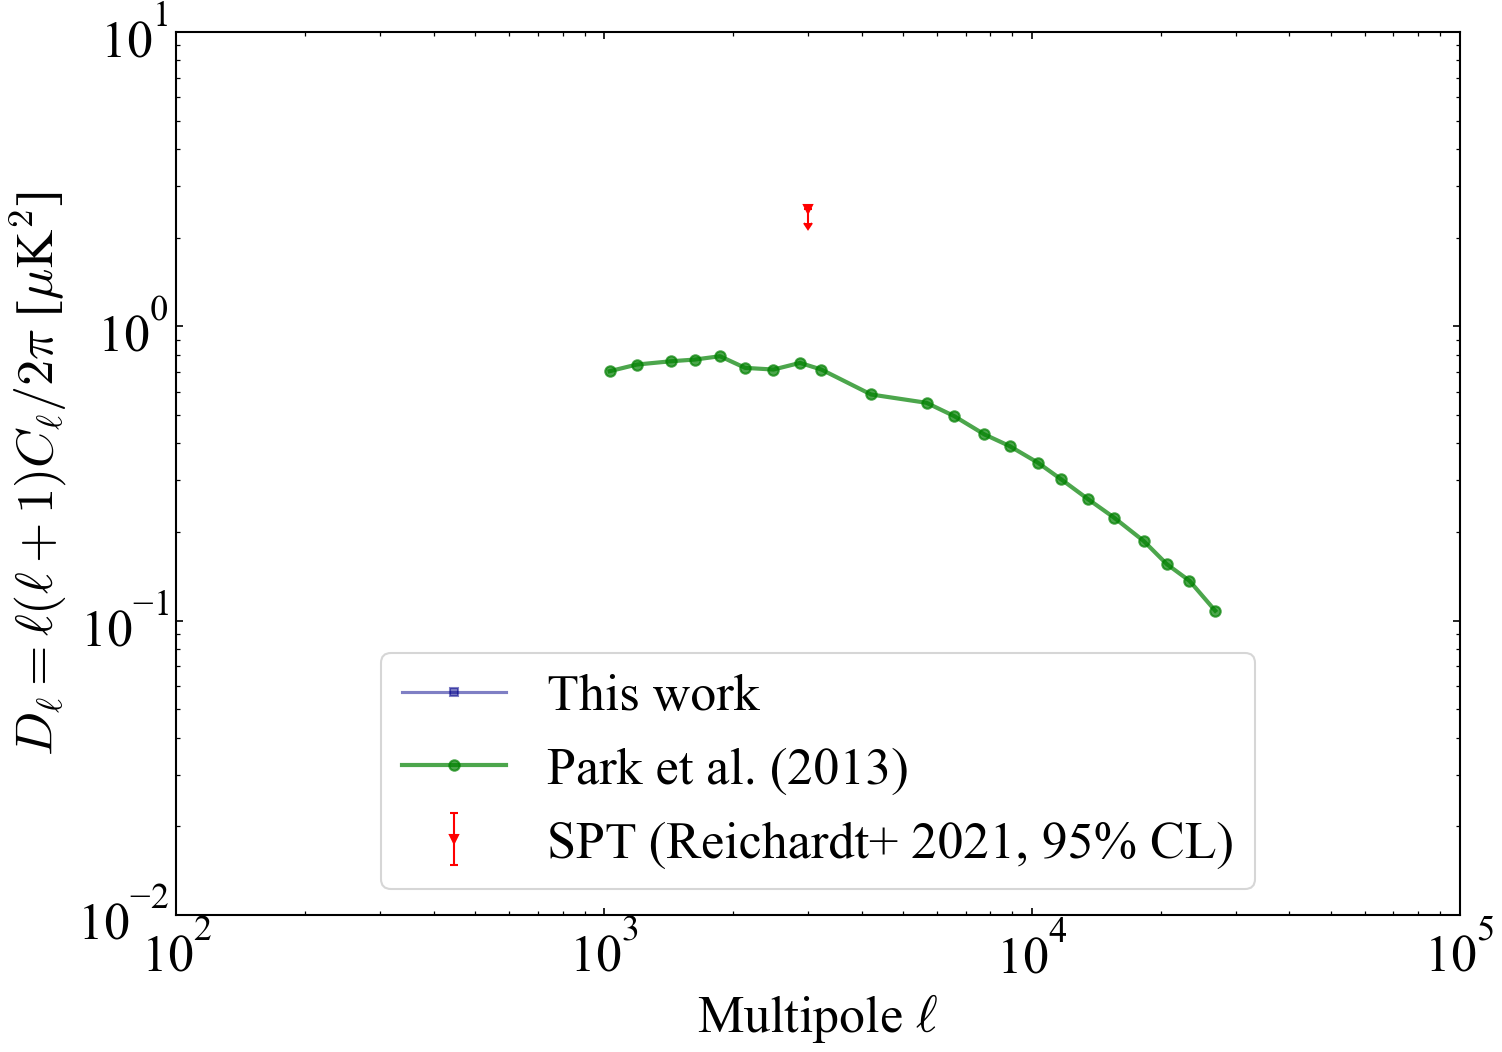

Saved: kSZ_Dl_muK2


In [25]:
from matplotlib.ticker import LogLocator, LogFormatterMathtext
import numpy as np

def plot_Dl_muK2(ax):
    valid = ~np.isnan(Dl_uK2_DA) & (Dl_uK2_DA > 0) & (ell_from_k > 10)
    ax.loglog(
        ell_from_k[valid], Dl_uK2_DA[valid],
        's-', color='darkblue', alpha=0.5,
        linewidth=1.5, markersize=4,
        label=r'This work'
    )
    
    # -------------------------------------------------
    # Load and plot Park et al. 2013 data
    # -------------------------------------------------
    park_data = np.loadtxt('Park2013_pkSZ_L3.csv', delimiter=',')
    park_ell = park_data[:, 0]
    park_Dl = park_data[:, 1]
    ax.loglog(
        park_ell, park_Dl,
        'o-', color='green', alpha=0.7,
        linewidth=2, markersize=5,
        label='Park et al. (2013)'
    )
    
    # -------------------------------------------------
    # 95% CL upper limit: SPT (Reichardt et al. 2021)
    # -------------------------------------------------
    # -------------------------------------------------
# 95% CL upper limit: SPT (Reichardt et al. 2021)
# -------------------------------------------------
    # -------------------------------------------------
# 95% CL upper limit: SPT (Reichardt et al. 2021)
# -------------------------------------------------
    ell_ul = 3000
    Dl_ul_95 = 2.5  # μK^2
    ax.errorbar(
        ell_ul, Dl_ul_95,
        yerr=[[Dl_ul_95 * 0.1], [0.0]],  # Reduced from 0.8 to 0.3
        uplims=True,
        fmt='v',
        color='red',
        markersize=4,
        capsize=2,
        capthick=1.0,
        elinewidth=1.0,
        label='SPT (Reichardt+ 2021, 95% CL)'
    )
    ax.set_xlim(1e2, 1e5)
    ax.set_ylim(1e-2, 1e1)
    
    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=(2,3,4,5,6,7,8,9)))
    ax.xaxis.set_major_formatter(LogFormatterMathtext())
    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2,3,4,5,6,7,8,9)))
    ax.yaxis.set_major_formatter(LogFormatterMathtext())
    
    ax.set_xlabel(r'Multipole $\ell$')
    ax.set_ylabel(r'$D_\ell = \ell(\ell+1)C_\ell / 2\pi$ [$\mu$K$^2$]')
    ax.legend(loc='lower center')

plot_name = "kSZ_Dl_muK2"

# -------- Preview PDF style --------
with mpl.rc_context(PNG_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
    plot_Dl_muK2(ax)
    plt.show()

# -------- Save PDF + PNG --------
save_pdf_png(
    plot_func=plot_Dl_muK2,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Angular Power Spectrum $D_\ell$"
)
print(f"Saved: {plot_name}")

In [12]:
# =============================================================================
# ERROR PROPAGATION: P(k) → C_ℓ → D_ℓ
# =============================================================================

print(f"\n{'='*60}")
print(f"ERROR PROPAGATION")
print(f"{'='*60}")

# You already have P1d_err from your azimuthal averaging
# This represents the sample variance in P(k)

# -----------------------------------------------------------------------------
# 1. Propagate to C_ℓ
# -----------------------------------------------------------------------------
# Transformation: C_ℓ = P(k) / D_A²
# Therefore: σ(C_ℓ) = σ(P(k)) / D_A²

Cl_kSZ_DA_err = P1d_err * 0.67**2 / D_A_physical**2

print(f"\n=== C_ℓ ERRORS ===")
valid_Cl = ~np.isnan(Cl_kSZ_DA) & (Cl_kSZ_DA > 0)
if np.sum(valid_Cl) > 0:
    rel_err_Cl = Cl_kSZ_DA_err[valid_Cl] / Cl_kSZ_DA[valid_Cl]
    print(f"Relative error in C_ℓ: {np.nanmean(rel_err_Cl)*100:.1f}% (mean)")
    print(f"Range: {np.nanmin(rel_err_Cl)*100:.1f}% - {np.nanmax(rel_err_Cl)*100:.1f}%")

# -----------------------------------------------------------------------------
# 2. Propagate to D_ℓ (before CMB temperature scaling)
# -----------------------------------------------------------------------------
# Transformation: D_ℓ = ℓ(ℓ+1) C_ℓ / (2π)
# Therefore: σ(D_ℓ) = ℓ(ℓ+1) σ(C_ℓ) / (2π)

Dl_kSZ_muK2_DA_err = ell_from_k * (ell_from_k + 1) * Cl_kSZ_DA_err / (2 * np.pi)

print(f"\n=== D_ℓ ERRORS (dimensionless) ===")
valid_Dl = ~np.isnan(Dl_kSZ_muK2_DA) & (Dl_kSZ_muK2_DA > 0)
if np.sum(valid_Dl) > 0:
    rel_err_Dl = Dl_kSZ_muK2_DA_err[valid_Dl] / Dl_kSZ_muK2_DA[valid_Dl]
    print(f"Relative error in D_ℓ: {np.nanmean(rel_err_Dl)*100:.1f}% (mean)")
    print(f"Range: {np.nanmin(rel_err_Dl)*100:.1f}% - {np.nanmax(rel_err_Dl)*100:.1f}%")

# -----------------------------------------------------------------------------
# 3. Propagate to D_ℓ in μK²
# -----------------------------------------------------------------------------
# Transformation: D_ℓ[μK²] = D_ℓ × T_CMB²(z=5)
# Therefore: σ(D_ℓ[μK²]) = σ(D_ℓ) × T_CMB²(z=5)

Dl_uK2_DA_err = Dl_kSZ_muK2_DA_err * T_CMB_z5_uK**2

print(f"\n=== D_ℓ ERRORS (μK²) ===")
if np.sum(valid_Dl) > 0:
    print(f"Absolute error range: {np.nanmin(Dl_uK2_DA_err[valid_Dl]):.4e} - {np.nanmax(Dl_uK2_DA_err[valid_Dl]):.4e} μK²")
    # Relative error is the same as dimensionless D_ℓ
    print(f"Relative error: same as dimensionless D_ℓ ({np.nanmean(rel_err_Dl)*100:.1f}% mean)")

print(f"{'='*60}")


ERROR PROPAGATION

=== C_ℓ ERRORS ===
Relative error in C_ℓ: 10.9% (mean)
Range: 2.0% - 40.2%

=== D_ℓ ERRORS (dimensionless) ===
Relative error in D_ℓ: 10.9% (mean)
Range: 2.0% - 40.2%

=== D_ℓ ERRORS (μK²) ===
Absolute error range: 1.1430e-03 - 1.1290e-01 μK²
Relative error: same as dimensionless D_ℓ (10.9% mean)


In [26]:
# =============================================================================
# UPDATED PLOT 2: C_ℓ with error bars
# =============================================================================

def plot_Cl(ax):
    valid = ~np.isnan(Cl_kSZ_DA) & (Cl_kSZ_DA > 0) & (ell_from_k > 10)

    ax.errorbar(
        ell_from_k[valid], Cl_kSZ_DA[valid],
        yerr=Cl_kSZ_DA_err[valid],
        fmt='o-', color='blue',
        alpha=0.7, linewidth=1.5, markersize=4,
        capsize=3, capthick=1,
        label=r'$C_\ell$ (with sample variance)'
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'Multipole $\ell$')
    ax.set_ylabel(r'$C_\ell$ [$\mu$K$^2$]')
    ax.legend(loc='best')


plot_name = "kSZ_Cl_corrected"

# -------- Preview with error bars --------
with mpl.rc_context(PDF_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
    plot_Cl(ax)
    plt.show()  # <--- ADD THIS LINE

# -------- Save PDF + PNG --------
save_pdf_png(
    plot_func=plot_Cl,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Angular Power Spectrum $C_\ell$"
)

print(f"Saved: {plot_name}")


# =============================================================================
# UPDATED PLOT 3: D_ℓ with error bars
# =============================================================================

def plot_Dl_muK2(ax):
    valid = ~np.isnan(Dl_uK2_DA) & (Dl_uK2_DA > 0) & (ell_from_k > 10)

    ax.errorbar(
        ell_from_k[valid], Dl_uK2_DA[valid],
        yerr=Dl_uK2_DA_err[valid],
        fmt='s-', color='darkblue', alpha=0.6,
        linewidth=1.5, markersize=4,
        capsize=3, capthick=1,
        label=r'$D_\ell$ (with sample variance)'
    )

    # SPT upper limit
    ell_ul = 3000
    Dl_ul_95 = 2.5
    ax.errorbar(
        ell_ul, Dl_ul_95,
        yerr=[[Dl_ul_95 * 0.01], [0.0]],
        uplims=True,
        fmt='v',
        color='red',
        markersize=10,
        capsize=5,
        label='SPT (Reichardt+ 2021, 95% CL)'
    )

    ax.set_xlim(1e2, 1e4)
    ax.set_ylim(1e-2, 1e1)
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=(2,3,4,5,6,7,8,9)))
    ax.xaxis.set_major_formatter(LogFormatterMathtext())

    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2,3,4,5,6,7,8,9)))
    ax.yaxis.set_major_formatter(LogFormatterMathtext())

    ax.set_xlabel(r'Multipole $\ell$')
    ax.set_ylabel(r'$D_\ell = \ell(\ell+1)C_\ell / 2\pi$ [$\mu$K$^2$]')
    ax.legend(loc='lower center')


plot_name = "kSZ_Dl_muK2"

# -------- Preview with error bars --------
with mpl.rc_context(PDF_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
    plot_Dl_muK2(ax)
    plt.show()  # <--- ADD THIS LINE

# -------- Save PDF + PNG --------
save_pdf_png(
    plot_func=plot_Dl_muK2,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Angular Power Spectrum $D_\ell$"
)

print(f"Saved: {plot_name}")


# =============================================================================
# UPDATED PLOT 4: D_ℓ with observations and error bars
# =============================================================================

def plot_Dl_muK2_with_obs(ax):
    valid = ~np.isnan(Dl_uK2_DA) & (Dl_uK2_DA > 0) & (ell_from_k > 10)

    ax.errorbar(
        ell_from_k[valid], Dl_uK2_DA[valid],
        yerr=Dl_uK2_DA_err[valid],
        fmt='s-', color='orange', alpha=0.6,
        linewidth=1.5, markersize=4,
        capsize=3, capthick=1,
        label='This work (using $D_A$, incorrect)',
        zorder=5
    )

    # Alvarez et al. (2016)
    try:
        data = np.loadtxt("Alvarez2016_binned_smoothed.txt")
        ax.loglog(
            data[:, 0], data[:, 1],
            lw=2.5, ls='--', color='black',
            label='Alvarez et al. (2016)',
            alpha=0.7, zorder=5
        )
    except FileNotFoundError:
        pass

    # Reichardt et al. (2021)
    ax.errorbar(
        3000, 1.1,
        yerr=[[0.7], [1.0]],
        fmt='s', markersize=10,
        capsize=5, capthick=2,
        color='red',
        label='Reichardt et al. (2021)',
        zorder=15
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'Multipole $\ell$')
    ax.set_ylabel(r'$D_\ell$ [$\mu$K$^2$]')
    ax.legend(loc='best', frameon=True, framealpha=0.95)

    info_text = (
        f"Box: {user_params.BOX_LEN:.0f} Mpc, "
        f"z = {red_axis.min():.1f}-{red_axis.max():.1f}\n"
        f"$D_A$ = {D_A_physical:.0f} Mpc"
    )
    ax.text(
        0.05, 0.05, info_text,
        transform=ax.transAxes,
        fontsize=20,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )


plot_name = "kSZ_Dl_muK2_with_observations"

# -------- Preview with error bars --------
with mpl.rc_context(PDF_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
    plot_Dl_muK2_with_obs(ax)
    plt.show()  # <--- ADD THIS LINE

# -------- Save PDF + PNG --------
save_pdf_png(
    plot_func=plot_Dl_muK2_with_obs,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Angular Power $D_\ell$: Comparison with Observations"
)

print(f"Saved: {plot_name}")

NameError: name 'Cl_kSZ_DA_err' is not defined

In [14]:
# =============================================================================
# COMPLETE ERROR BUDGET
# =============================================================================

print(f"\n{'='*60}")
print(f"COMPLETE ERROR BUDGET")
print(f"{'='*60}")

# -----------------------------------------------------------------------------
# 1. Sample variance (what you already have)
# -----------------------------------------------------------------------------
P1d_err_sample = P1d_err.copy()

# -----------------------------------------------------------------------------
# 2. Cosmic variance
# -----------------------------------------------------------------------------
# Number of modes in each k-bin
k_volume = (box_size_Mpc / (2*np.pi))**3  # (L/2π)³ in units where k is in Mpc⁻¹
n_modes = 4 * np.pi * k_centers**2 * k_volume * (k_bins[1:] - k_bins[:-1])

# Cosmic variance fractional error: 1/√N_modes
cosmic_var_frac = 1.0 / np.sqrt(n_modes)
P1d_err_cosmic = P1d * cosmic_var_frac

print(f"\n=== COSMIC VARIANCE ===")
print(f"Number of modes per bin: {n_modes[n_modes>0].min():.1f} - {n_modes.max():.1f}")
print(f"Cosmic variance: {cosmic_var_frac[n_modes>0].min()*100:.1f}% - {cosmic_var_frac.max()*100:.1f}%")

# -----------------------------------------------------------------------------
# 3. Combine sample and cosmic variance (in quadrature)
# -----------------------------------------------------------------------------
P1d_err_total = np.sqrt(P1d_err_sample**2 + P1d_err_cosmic**2)

print(f"\n=== COMBINED P(k) ERRORS ===")
valid = ~np.isnan(P1d) & (P1d > 0)
rel_err_sample = P1d_err_sample[valid] / P1d[valid]
rel_err_cosmic = P1d_err_cosmic[valid] / P1d[valid]
rel_err_total = P1d_err_total[valid] / P1d[valid]

print(f"Sample variance:  {np.nanmean(rel_err_sample)*100:.1f}% (mean)")
print(f"Cosmic variance:  {np.nanmean(rel_err_cosmic)*100:.1f}% (mean)")
print(f"Total variance:   {np.nanmean(rel_err_total)*100:.1f}% (mean)")


# -----------------------------------------------------------------------------
# 5. Propagate total errors to C_ℓ and D_ℓ
# -----------------------------------------------------------------------------

# Statistical errors (sample + cosmic variance)
Cl_kSZ_DA_err_stat = P1d_err_total * 0.67**2 / D_A_physical**2
Dl_kSZ_muK2_DA_err_stat = ell_from_k * (ell_from_k + 1) * Cl_kSZ_DA_err_stat / (2 * np.pi)
Dl_uK2_DA_err_stat = Dl_kSZ_muK2_DA_err_stat * T_CMB_z5_uK**2


# Total error (quadrature sum)
# Total error = statistical only (sample + cosmic variance)
Dl_uK2_DA_err_total = Dl_uK2_DA_err_stat

print(f"\n=== FINAL D_ℓ ERRORS ===")
valid_Dl = ~np.isnan(Dl_uK2_DA) & (Dl_uK2_DA > 0)
print(f"Total error (sample + cosmic): {np.nanmean(Dl_uK2_DA_err_total[valid_Dl]/Dl_uK2_DA[valid_Dl])*100:.1f}% (mean)")
print(f"\n=== FINAL D_ℓ ERRORS ===")
valid_Dl = ~np.isnan(Dl_uK2_DA) & (Dl_uK2_DA > 0)
print(f"Statistical error: {np.nanmean(Dl_uK2_DA_err_stat[valid_Dl]/Dl_uK2_DA[valid_Dl])*100:.1f}% (mean)")
print(f"Systematic error:  {np.nanmean(Dl_uK2_DA_err_sys[valid_Dl]/Dl_uK2_DA[valid_Dl])*100:.1f}% (mean)")
print(f"Total error:       {np.nanmean(Dl_uK2_DA_err_total[valid_Dl]/Dl_uK2_DA[valid_Dl])*100:.1f}% (mean)")

print(f"{'='*60}")

# =============================================================================
# UPDATED PLOT 3: D_ℓ with COMBINED error bars
# =============================================================================
def plot_Dl_muK2(ax):
    valid = ~np.isnan(Dl_uK2_DA) & (Dl_uK2_DA > 0) & (ell_from_k > 10)
    
    # Plot with TOTAL errors (statistical + systematic)
    ax.errorbar(
        ell_from_k[valid], Dl_uK2_DA[valid],
        yerr=Dl_uK2_DA_err_total[valid],  # <--- CHANGED to total errors
        fmt='s-', color='darkblue', alpha=0.6,
        linewidth=1.5, markersize=4,
        capsize=3, capthick=1,
        label=r'$D_\ell$ '
    )
    
    # Optionally: show just statistical errors as a lighter band
    ax.fill_between(
        ell_from_k[valid],
        Dl_uK2_DA[valid] - Dl_uK2_DA_err_stat[valid],
        Dl_uK2_DA[valid] + Dl_uK2_DA_err_stat[valid],
        alpha=0.2, color='darkblue',
        label='Sample + Cosmic Variance'
    )
    
    # SPT upper limit
    ell_ul = 3000
    Dl_ul_95 = 2.5
    ax.errorbar(
        ell_ul, Dl_ul_95,
        yerr=[[Dl_ul_95 * 0.01], [0.0]],
        uplims=True,
        fmt='v',
        color='red',
        markersize=10,
        capsize=5,
        label='SPT (Reichardt+ 2021, 95% CL)'
    )
    
    ax.set_xlim(1e2, 1e4)
    ax.set_ylim(1e-2, 1e1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=(2,3,4,5,6,7,8,9)))
    ax.xaxis.set_major_formatter(LogFormatterMathtext())
    
    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2,3,4,5,6,7,8,9)))
    ax.yaxis.set_major_formatter(LogFormatterMathtext())
    
    ax.set_xlabel(r'Multipole $\ell$')
    ax.set_ylabel(r'$D_\ell = \ell(\ell+1)C_\ell / 2\pi$ [$\mu$K$^2$]')
    ax.legend(loc='lower center', fontsize=10)


plot_name = "kSZ_Dl_muK2"

# -------- Preview with error bars --------
with mpl.rc_context(PDF_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
    plot_Dl_muK2(ax)
    plt.show()

# -------- Save PDF + PNG --------
save_pdf_png(
    plot_func=plot_Dl_muK2,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Angular Power Spectrum $D_\ell$"
)

print(f"Saved: {plot_name}")


COMPLETE ERROR BUDGET

=== COSMIC VARIANCE ===
Number of modes per bin: 2.0 - 727477.7
Cosmic variance: 0.1% - 71.0%

=== COMBINED P(k) ERRORS ===
Sample variance:  10.9% (mean)
Cosmic variance:  6.3% (mean)
Total variance:   13.3% (mean)

=== FINAL D_ℓ ERRORS ===
Total error (sample + cosmic): 13.3% (mean)

=== FINAL D_ℓ ERRORS ===
Statistical error: 13.3% (mean)


NameError: name 'Dl_uK2_DA_err_sys' is not defined

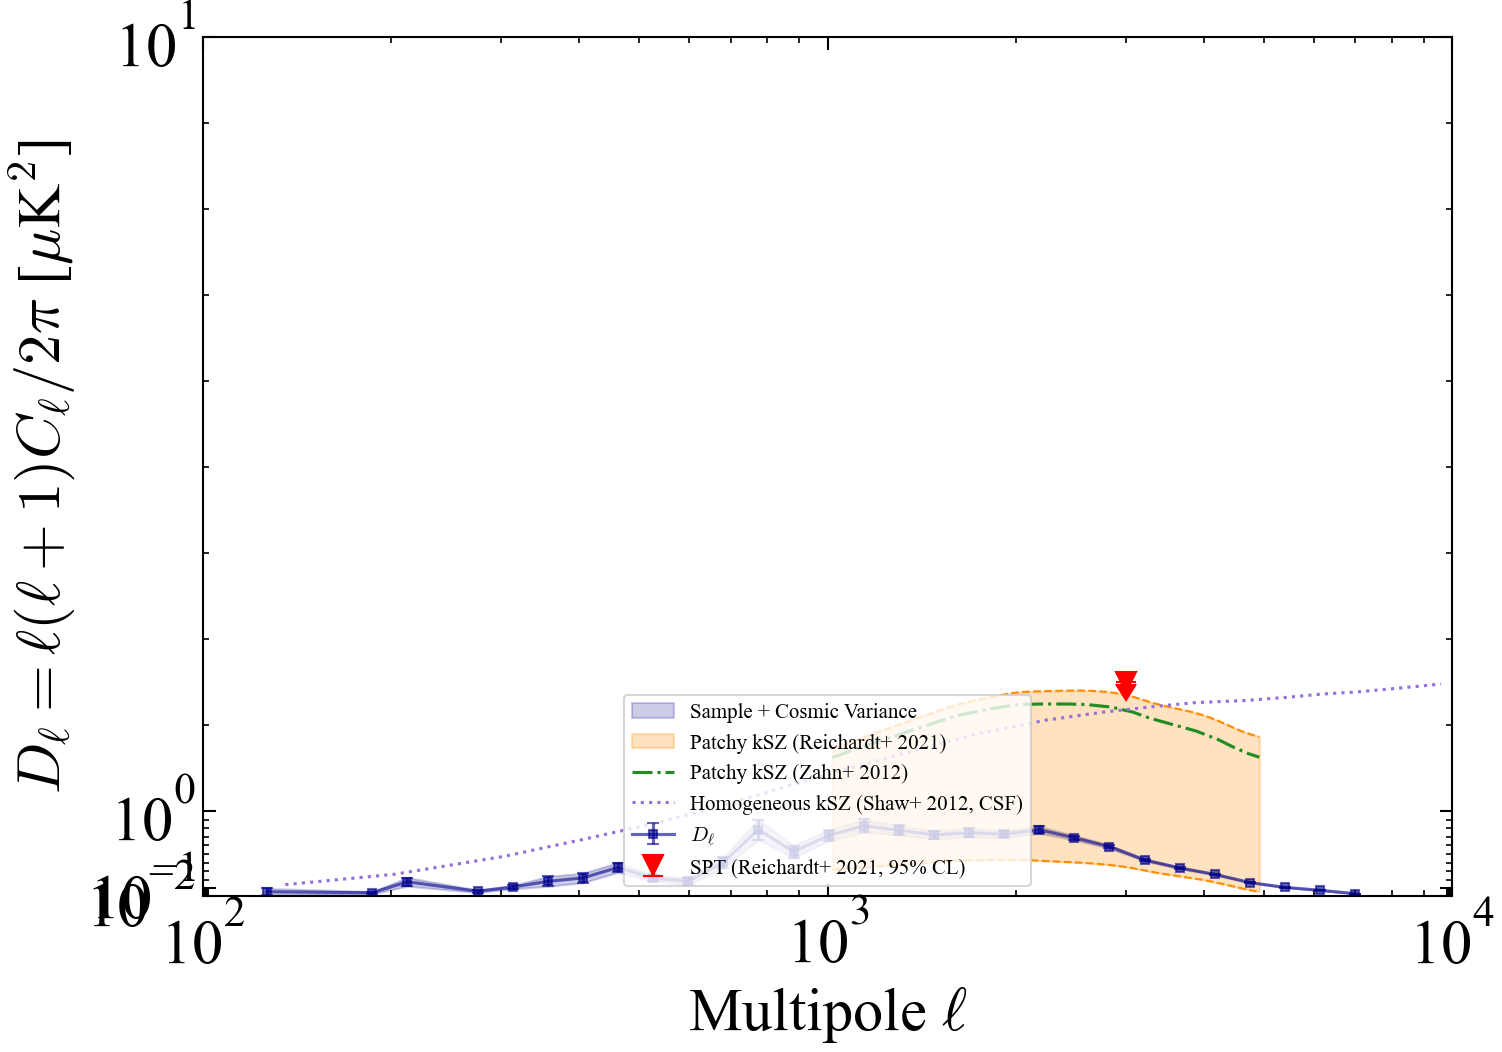

Saved: kSZ_Dl_muK2_with_obs_spread


In [22]:
# Load Reichardt+2021 patchy kSZ bounds (do this once, outside the plot function)
reichardt_lower = np.loadtxt('patchy_lower_error_Reichardt21.csv', delimiter=',', skiprows=1)
reichardt_upper = np.loadtxt('patchy_upper_error_Reichardt21.csv', delimiter=',', skiprows=1)

# Load patchy kSZ templates (do this once, outside the plot function)
zahn2012_patchy  = np.loadtxt('Zahn2012_Patchy_template.csv',  delimiter=',')
shaw12_csf_homo  = np.loadtxt('Shaw12_CSF_homo.csv',            delimiter=',')

def plot_Dl_muK2_with_obs_spread(ax):
    valid = ~np.isnan(Dl_uK2_DA) & (Dl_uK2_DA > 0) & (ell_from_k > 10)

    # Plot with TOTAL errors (statistical + systematic)
    ax.errorbar(
        ell_from_k[valid], Dl_uK2_DA[valid],
        yerr=Dl_uK2_DA_err_total[valid],
        fmt='s-', color='darkblue', alpha=0.6,
        linewidth=1.5, markersize=4,
        capsize=3, capthick=1,
        label=r'$D_\ell$ '
    )

    # Optionally: show just statistical errors as a lighter band
    ax.fill_between(
        ell_from_k[valid],
        Dl_uK2_DA[valid] - Dl_uK2_DA_err_stat[valid],
        Dl_uK2_DA[valid] + Dl_uK2_DA_err_stat[valid],
        alpha=0.2, color='darkblue',
        label='Sample + Cosmic Variance'
    )

    # ── Reichardt+2021 patchy kSZ band ──────────────────────────────────────
    ell_lo  = reichardt_lower[:, 0]
    Dl_lo   = reichardt_lower[:, 1]
    ell_hi  = reichardt_upper[:, 0]
    Dl_hi   = reichardt_upper[:, 1]

    Dl_hi_interp = np.interp(ell_lo, ell_hi, Dl_hi)
    ax.fill_between(
        ell_lo, Dl_lo, Dl_hi_interp,
        alpha=0.25, color='darkorange',
        label='Patchy kSZ (Reichardt+ 2021)'
    )
    ax.plot(ell_lo, Dl_lo,        color='darkorange', linewidth=1.0, linestyle='--')
    ax.plot(ell_lo, Dl_hi_interp, color='darkorange', linewidth=1.0, linestyle='--')
    # ────────────────────────────────────────────────────────────────────────

    # ── Zahn+2012 patchy kSZ template ───────────────────────────────────────
    ax.plot(
        zahn2012_patchy[:, 0], zahn2012_patchy[:, 1],
        color='forestgreen', linewidth=1.5, linestyle='-.',
        label='Patchy kSZ (Zahn+ 2012)'
    )
    # ────────────────────────────────────────────────────────────────────────

    # ── Shaw+2012 CSF homogeneous kSZ template ───────────────────────────────
    ax.plot(
        shaw12_csf_homo[:, 0], shaw12_csf_homo[:, 1],
        color='mediumpurple', linewidth=1.5, linestyle=':',
        label='Homogeneous kSZ (Shaw+ 2012, CSF)'
    )
    # ────────────────────────────────────────────────────────────────────────

    # SPT upper limit
    ell_ul    = 3000
    Dl_ul_95  = 2.5
    ax.errorbar(
        ell_ul, Dl_ul_95,
        yerr=[[Dl_ul_95 * 0.01], [0.0]],
        uplims=True, fmt='v', color='red',
        markersize=10, capsize=5,
        label='SPT (Reichardt+ 2021, 95% CL)'
    )

    ax.set_xlim(1e2, 1e4)
    ax.set_ylim(1e-2, 1e1)
    ax.set_xscale('log')
    #ax.set_yscale('log')
    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=(2,3,4,5,6,7,8,9)))
    ax.xaxis.set_major_formatter(LogFormatterMathtext())
    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2,3,4,5,6,7,8,9)))
    ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.set_xlabel(r'Multipole $\ell$')
    ax.set_ylabel(r'$D_\ell = \ell(\ell+1)C_\ell / 2\pi$ [$\mu$K$^2$]')
    ax.legend(loc='lower center', fontsize=10)
    # -------- Define plot name --------
plot_name = "kSZ_Dl_muK2_with_obs_spread"

# -------- Preview with error bars --------
with mpl.rc_context(PDF_STYLE):
    fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
    plot_Dl_muK2_with_obs_spread(ax)
    plt.show()

# -------- Save PDF + PNG --------
save_pdf_png(
    plot_func=plot_Dl_muK2_with_obs,
    plot_dir=plot_dir,
    plot_name=plot_name,
    title=r"kSZ Angular Power $D_\ell$: Comparison with Observations"
)

print(f"Saved: {plot_name}")

In [19]:
# =============================================================================
# CELL: Extract curve and error bars
# =============================================================================
import sys
!{sys.executable} -m pip install pytz pandas --quiet

import pandas as pd
from pathlib import Path

valid = ~np.isnan(Dl_uK2_DA) & (Dl_uK2_DA > 0) & (ell_from_k > 10)
# ── Central curve ──────────────────────────────────────────────────────────
ell_out        = ell_from_k[valid]
Dl_out         = Dl_uK2_DA[valid]
# ── Error bars ─────────────────────────────────────────────────────────────
Dl_err_stat    = Dl_uK2_DA_err_stat[valid]    # sample + cosmic variance
Dl_err_total   = Dl_uK2_DA_err_total[valid]   # total (stat + systematic)
# ── Asymmetric format (for errorbar plots) ─────────────────────────────────
Dl_err_lo      = Dl_err_total                  # lower bar  (symmetric here)
Dl_err_hi      = Dl_err_total                  # upper bar  (symmetric here)
# ── Summary ────────────────────────────────────────────────────────────────
print(f"Extracted {ell_out.size} ell bins")
print(f"ell range:         {ell_out.min():.1f}  –  {ell_out.max():.1f}")
print(f"Dl  range:         {Dl_out.min():.3e}  –  {Dl_out.max():.3e}  µK²")
print(f"Stat  error (mean):  {(Dl_err_stat  / Dl_out).mean()*100:.1f}%")
print(f"Total error (mean):  {(Dl_err_total / Dl_out).mean()*100:.1f}%")
# ── Save to CSV ─────────────────────────────────────────────────────────────
df_out = pd.DataFrame({
    'ell':           ell_out,
    'Dl_uK2':        Dl_out,
    'Dl_err_stat':   Dl_err_stat,
    'Dl_err_total':  Dl_err_total,
    'Dl_lower':      Dl_out - Dl_err_total,
    'Dl_upper':      Dl_out + Dl_err_total,
})
csv_path = Path(plot_dir) / "Self_pkSZ_Dl.csv"
df_out.to_csv(csv_path, index=False)
print(f"\nSaved extracted curve → {csv_path}")

Extracted 29 ell bins
ell range:         126.6  –  6996.1
Dl  range:         3.972e-02  –  8.274e-01  µK²
Stat  error (mean):  13.3%
Total error (mean):  13.3%

Saved extracted curve → 25Feb26_lightcone_plots_v3/Self_pkSZ_Dl.csv
